In [1009]:
# Start with the CFS (2017)
import pyxlsb
import pandas as pd
cfs_path = '/Users/jeffreyohl/Dropbox/SpatialW25/BigDataFiles/pset2/CFS/'
cfs_mapping_path = "/Users/jeffreyohl/Dropbox/SpatialW25/BigDataFiles/pset2/Mapping Files/CFS_sector_aggregation.xlsx"
wiod_path = "/Users/jeffreyohl/Dropbox/SpatialW25/BigDataFiles/pset2/WIOD/WIOT2014_Nov16_ROW.xlsb"
wiod_mapping_sector_path = "/Users/jeffreyohl/Dropbox/SpatialW25/BigDataFiles/pset2/Mapping Files/WIOD_sector_aggregation.xlsx"
out_folder = "/Users/jeffreyohl/Dropbox/SpatialW25/BigDataFiles/pset2/X_in_j/"
out_folder_IO = '/Users/jeffreyohl/Dropbox/SpatialW25/BigDataFiles/pset2/IO/'
out_folder_gamma = '/Users/jeffreyohl/Dropbox/SpatialW25/BigDataFiles/pset2/gamma/'

out_folder_GO = '/Users/jeffreyohl/Dropbox/SpatialW25/BigDataFiles/pset2/GO/'
countries_path = "/Users/jeffreyohl/Dropbox/SpatialW25/BigDataFiles/pset2/Mapping Files/WIOD_country_codes.csv"



# E.g. CHE, HRV, LUX, LVA, MLT, NOR => "ROW"
row_countries = ["CHE", "HRV", "LUX", "LVA", "MLT", "NOR"]

mapping = pd.read_excel(wiod_mapping_sector_path)
out_map = mapping.set_index('output_code')['OrderExcldNon'].to_dict()
in_map  = mapping.set_index('input_code')['OrderExcldNon'].to_dict()

In [1010]:
country = pd.read_csv(countries_path)

In [1011]:
country.head()

,Code,CountryLong,Country,up to row.,end here
0,AUS,Australia,1,22.0,44.0
1,AUT,Austria,2,44.0,66.0
2,BEL,Belgium,3,66.0,88.0
3,BGR,Bulgaria,4,88.0,110.0
4,BRA,Brazil,5,110.0,132.0


In [1012]:
country_map = country.set_index('Code')['Country'].to_dict()


# WIOD 2014

In [1013]:


# ------------------------------
# 1) Read the matrix from Excel
# ------------------------------
# - skiprows=4 so that the first row we read is row 5 of the sheet
# - header=[0,1] means: the first two rows we read become a 2-level column header
#   (row 5 is level 0: "ImportingCountry", row 6 is level 1: "ImportingIndustry")
# - index_col=[2,3] means: use columns C and D (zero-based: 2 and 3) as the row index
#   (ExportingCountry, ExportingIndustry)
df = pd.read_excel(
    wiod_path,
    sheet_name="2014",
    skiprows=4,        # Adjust if you have more or fewer label rows
    header=[0, 1],     # Row 5 => upper col labels, Row 6 => lower col labels
    index_col=[2, 3],  # Column C => ExportingCountry, Column D => ExportingIndustry
    # usecols="C:ZZ",  # Optionally restrict columns if needed
)


In [1014]:
df

Unnamed: 0_level_0                                 Unnamed: 1_level_0  \
        Unnamed: 0_level_1                                 Unnamed: 1_level_1   
AUS r1                 A01  Crop and animal production, hunting and relate...   
    r2                 A02                               Forestry and logging   
    r3                 A03                            Fishing and aquaculture   
    r4                   B                               Mining and quarrying   
    r5             C10-C12  Manufacture of food products, beverages and to...   
...                    ...                                                ...   
TOT r68               PURR               Direct purchases abroad by residents   
    r69              PURNR  Purchases on the domestic territory by non-res...   
    r70                 VA                        Value added at basic prices   
    r71             IntTTM                    International Transport Margins   
    r73                 GO                             Output at basic prices   

                  AUS                                                         \
                   c1           c2           c3             c4            c5   
AUS r1   12924.179691   112.454221   228.480462     538.890807  25139.334287   
    r2      83.029637   201.499948     0.191313      17.190679      2.646331   
    r3      19.147731     0.001079    19.106701       4.228108    316.075149   
    r4     115.929847     0.695040     5.924477    4492.037652    331.609356   
    r5    1590.840590     0.880063    42.540760     203.011938  10851.759013   
...               ...          ...          ...            ...           ...   
TOT r68      0.000000     0.000000     0.000000       0.000000      0.000000   
    r69      0.000000     0.000000     0.000000       0.000000      0.000000   
    r70  30489.190204  1569.898939  1894.738465   98315.119874  24247.396178   
    r71    261.678718    22.216736    23.867813     946.487471    240.331290   
    r73  70292.034492  2585.379685  3175.044396  171985.122327  83504.036584   

                                                ... USA                \
                  c6           c7           c8  ... c58           c59   
AUS r1    737.492591     4.475430     3.130541  ...   0  3.565392e-05   
    r2      0.093768  1430.804904     0.369454  ...   0  1.647680e-06   
    r3     22.866683     0.252294     0.268537  ...   0  5.445825e-07   
    r4      5.984141    29.740924    49.763961  ...   0  1.767029e-04   
    r5    262.228559    11.467425    18.140557  ...   0  1.528107e-04   
...              ...          ...          ...  ...  ..           ...   
TOT r68     0.000000     0.000000     0.000000  ...   0  0.000000e+00   
    r69     0.000000     0.000000     0.000000  ...   0  0.000000e+00   
    r70  2335.770879  3382.997589  2463.259348  ...   0  0.000000e+00   
    r71    56.748232    27.522875    68.402006  ...   0  0.000000e+00   
    r73  5064.024116  8999.775282  7925.229614  ...   0  0.000000e+00   

                                           ROW                       \
                  c60         c61          c57       c58        c59   
AUS r1       0.324914    0.027391   723.189984  0.000374  14.156350   
    r2       0.015015    0.000439     0.423422  0.000003   0.000071   
    r3       0.004963    0.008311   404.041139  0.000386   0.004619   
    r4       1.610294    0.047027    14.871627  0.006665   0.594705   
    r5       1.393463    0.041279  4810.234988  0.001371  47.016724   
...               ...         ...          ...       ...        ...   
TOT r68      0.000000    0.000000     0.000000  0.000000   0.000000   
    r69      0.000000    0.000000     0.000000  0.000000   0.000000   
    r70      0.000000    0.000000     0.000000  0.000000   0.000000   
    r71  22731.406982  738.023093     0.000000  0.000000   0.000000   
    r73      0.000000    0.000000     0.000000  0.000000   0.000000   

                                       

In [1015]:

# By default, pandas will name the two column levels something like (None, None).
# We can rename them:
df.columns.names = ["ImportingCountry", "ImportingIndustry"]
df.index.names = ["ExportingCountry", "ExportingIndustry"]



In [1016]:



# df is now a 2D table whose:
#   - row index = (ExportingCountry, ExportingIndustry)
#   - columns   = (ImportingCountry, ImportingIndustry)
#   - cell values = trade flows (or I/O flows).

# ------------------------------
# 2) Reshape from wide to long
# ------------------------------
# We "stack" over the two column levels:
df_long = df.stack(level=[0, 1]).reset_index()


/var/folders/g9/ggrmf_5j6tx4rv5qdhs0slq40000gn/T/ipykernel_87551/642626493.py:10: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df_long = df.stack(level=[0, 1]).reset_index()


In [1017]:
df_long

,ExportingCountry,ExportingIndustry,ImportingCountry,ImportingIndustry,0
0,AUS,r1,AUS,c1,12924.179691
1,AUS,r1,AUS,c2,112.454221
2,AUS,r1,AUS,c3,228.480462
3,AUS,r1,AUS,c4,538.890807
4,AUS,r1,AUS,c5,25139.334287
...,...,...,...,...,...
6642259,TOT,r73,USA,c59,0.0
6642260,TOT,r73,USA,c60,0.0
6642261,TOT,r73,USA,c61,0.0
6642262,TOT,r73,Unnamed: 0_level_0,Unnamed: 0_level_1,GO


In [1018]:
# Rename the last one to "Value" (or something relevant).
df_long.columns = [
    "ExportingCountry",
    "ExportingIndustry",
    "ImportingCountry",
    "ImportingIndustry",
    "Value",
]

# Get intermed. / value added / gross output.

In [1019]:
# Assume the following variables are defined:
# - row_countries: a list of countries to collapse into "ROW"
# - country_map: a dictionary to map country codes/names
# - out_map: a dictionary to map old ExportingIndustry codes to new sector codes
# - in_map: a dictionary to map old ImportingIndustry codes to new sector codes

def clean_and_aggregate(df):
    # 1. Collapse countries: replace any country in row_countries with "ROW"
    df["ImportingCountry"] = df["ImportingCountry"].where(~df["ImportingCountry"].isin(row_countries), "ROW")
    
    # 2. Initial aggregation on the key dimensions
    df_agg = df.groupby(
        ["ImportingCountry", "ImportingIndustry"],
        as_index=False
    )["Value"].sum()
    
    # 3. Rename countries using the provided mapping dictionary
  
    df_agg["ImportingCountry"] = df_agg["ImportingCountry"].map(country_map)
    
    # 4. Collapse sectors by mapping the industry codes
  
    df_agg["ImportingIndustry"] = df_agg["ImportingIndustry"].map(in_map)
    
    # 5. Drop rows with missing (NaN) values in the industry fields (if any)
    df_agg = df_agg.dropna(subset=[ "ImportingIndustry"])
    
    # 6. Re-aggregate in case the mapping has created duplicate rows
    df_final = df_agg.groupby(
        ["ImportingCountry", "ImportingIndustry"],
        as_index=False
    )["Value"].sum()
    df_final.columns = ['Country', 'Industry', 'Value']
    return df_final

# Create your three subsets based on ExportingIndustry codes
intermediate_consumption = df_long[df_long['ExportingIndustry'] == 'r65']
value_added = df_long[df_long['ExportingIndustry'] == 'r70']
gross_output = df_long[df_long['ExportingIndustry'] == 'r73']

# Apply the cleaning and aggregation function to each
intermediate_consumption_clean = clean_and_aggregate(intermediate_consumption)
value_added_clean = clean_and_aggregate(value_added)
gross_output_clean = clean_and_aggregate(gross_output)



/var/folders/g9/ggrmf_5j6tx4rv5qdhs0slq40000gn/T/ipykernel_87551/1150353327.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["ImportingCountry"] = df["ImportingCountry"].where(~df["ImportingCountry"].isin(row_countries), "ROW")
/var/folders/g9/ggrmf_5j6tx4rv5qdhs0slq40000gn/T/ipykernel_87551/1150353327.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["ImportingCountry"] = df["ImportingCountry"].where(~df["ImportingCountry"].isin(row_countries), "ROW")
/var/folders/g9/ggrmf_5j6tx4rv5qdhs0slq40000

In [1020]:
#fix USA
intermediate_consumption_clean['Country'] = intermediate_consumption_clean['Country'].replace(38, 0)
gross_output_clean['Country'] = gross_output_clean['Country'].replace(38, 0)
value_added_clean['Country'] = value_added_clean['Country'].replace(38,0)

In [1021]:

# The result has columns:
#   ["ExportingCountry", "ExportingIndustry", "ImportingCountry", "ImportingIndustry", 0]


# ------------------------------
# 3) Filter out invalid industries (optional)
# ------------------------------
# If valid industries are r1..r56 for exporting and c1..c56 for importing:


# ... this might changes total sales ... !!!!
valid_r = [f"r{i}" for i in range(1, 57)]
valid_c = [f"c{i}" for i in range(1, 57)]

df_long = df_long[
    df_long["ExportingIndustry"].isin(valid_r)
    & df_long["ImportingIndustry"].isin(valid_c)
]

# ------------------------------
# 4) Collapse certain countries
# ------------------------------

df_long["ExportingCountry"] = df_long["ExportingCountry"].where(
    ~df_long["ExportingCountry"].isin(row_countries), 
    "ROW"
)
df_long["ImportingCountry"] = df_long["ImportingCountry"].where(
    ~df_long["ImportingCountry"].isin(row_countries), 
    "ROW"
)

# ------------------------------
# 5) Summation / Aggregation
# ------------------------------
df_agg = df_long.groupby(
    ["ExportingCountry", "ExportingIndustry", 
     "ImportingCountry", "ImportingIndustry"],
    as_index=False
)["Value"].sum()



/var/folders/g9/ggrmf_5j6tx4rv5qdhs0slq40000gn/T/ipykernel_87551/1133600556.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_long["ExportingCountry"] = df_long["ExportingCountry"].where(
/var/folders/g9/ggrmf_5j6tx4rv5qdhs0slq40000gn/T/ipykernel_87551/1133600556.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_long["ImportingCountry"] = df_long["ImportingCountry"].where(


In [1022]:
df_agg['ExportingCountry'] = df_agg['ExportingCountry'].map(country_map)
df_agg['ImportingCountry'] = df_agg['ImportingCountry'].map(country_map)

In [1023]:
df_agg = df_agg.to_csv(out_folder + "long_fix_countries.csv")

In [1024]:
df_agg = pd.read_csv(out_folder + "long_fix_countries.csv")

In [1025]:
df_agg

,Unnamed: 0,ExportingCountry,ExportingIndustry,ImportingCountry,ImportingIndustry,Value
0,0,1,r1,1,c1,12924.179691
1,1,1,r1,1,c10,0.226825
2,2,1,r1,1,c11,86.721589
3,3,1,r1,1,c12,109.147573
4,4,1,r1,1,c13,147.252719
...,...,...,...,...,...,...
4528379,4528379,38,r9,38,c56,0.000000
4528380,4528380,38,r9,38,c6,743.552862
4528381,4528381,38,r9,38,c7,75.372114
4528382,4528382,38,r9,38,c8,208.748822


In [1026]:
%pip install openpyxl
import openpyxl

Note: you may need to restart the kernel to use updated packages.


In [1027]:
# 1) Build lookup dictionaries from your ‘mapping’ dataframe

df_agg_sector_fix = df_agg.copy()
# 2) Map the old codes in df_agg to the new “Order in CDP 2019” - 99 is anything missing.
df_agg_sector_fix['ExportingIndustry'] = df_agg_sector_fix['ExportingIndustry'].map(out_map)
df_agg_sector_fix['ImportingIndustry'] = df_agg_sector_fix['ImportingIndustry'].map(in_map)

# 3) Drop rows where either mapped industry is NaN ... should drop nothing.

df_agg_sector_fix = df_agg_sector_fix.dropna(subset=['ExportingIndustry','ImportingIndustry'])
# 4) Collapse (aggregate) non-unique rows, by summing 'Value'
df_agg_sector_fix = df_agg_sector_fix.groupby(
    ['ExportingCountry','ExportingIndustry','ImportingCountry','ImportingIndustry'],
    as_index=False
)['Value'].sum()


In [1028]:
# For example, save to CSV
df_agg_sector_fix.to_csv(out_folder+ "long_fix_countries_and_sectors.csv")


In [1029]:
us_code = country_map['USA']

In [1030]:
us_code

38

In [1031]:
domestic_usa_trade = df_agg_sector_fix[
    (df_agg_sector_fix['ExportingCountry'] == us_code) & 
    (df_agg_sector_fix['ImportingCountry'] == us_code )
]

# Group by exporting industry and sum Value
domestic_expenditure = domestic_usa_trade.groupby('ExportingIndustry', as_index=False)['Value'].sum()


In [1032]:
domestic_expenditure

,ExportingIndustry,Value
0,1.0,3.702758e+05
1,2.0,5.021600e+04
2,3.0,2.875896e+05
3,4.0,3.924727e+05
4,5.0,3.776814e+05
5,6.0,1.617610e+05
6,7.0,9.119060e+04
7,8.0,5.297387e+05
8,9.0,1.214166e+05
9,10.0,2.010416e+05


# ME THINKS THIS IS IN MILLIONS! (14.4M total about 1/1Mth of approx 11T in US TRADe..) I HOPE I AM RIGHT

In [1033]:
import pandas as pd

# Replace 'your_file.dta' with the path to your .dta file
cfs_2017 = pd.read_stata(cfs_path + 'states_ind_bilateral_trade2017.dta')


In [1034]:
cfs_2017['origin'] = cfs_2017['origin'].replace('District of Columbia', 'Virginia')
cfs_2017['dest'] = cfs_2017['dest'].replace('District of Columbia', 'Virginia')

In [1035]:
cfs_2017['origin'].unique()

array(['Arkansas', 'South Carolina', 'Maryland', 'Delaware', 'Wisconsin',
       'Massachusetts', 'Iowa', 'Colorado', 'Montana', 'Louisiana',
       'Kentucky', 'Idaho', 'New Mexico', 'Florida', 'Washington',
       'Hawaii', 'Texas', 'Missouri', 'California', 'Alaska', 'Utah',
       'Arizona', 'Nevada', 'Wyoming', 'Illinois', 'North Dakota',
       'Indiana', 'Georgia', 'Connecticut', 'New York', 'Mississippi',
       'North Carolina', 'Maine', 'Oklahoma', 'Alabama', 'Michigan',
       'Virginia', 'Nebraska', 'South Dakota', 'New Hampshire', 'Vermont',
       'Pennsylvania', 'West Virginia', 'Ohio', 'Kansas', 'New Jersey',
       'Minnesota', 'Oregon', 'Tennessee', 'Rhode Island',
       'United States'], dtype=object)

In [1036]:
cfs_2017 = cfs_2017[cfs_2017['origin_abrv'] != 'USA']


cfs_2017 = cfs_2017[cfs_2017['dest_abrv'] != 'USA']

# Display the first few rows of the dataframe
cfs_2017.head()

cfs_2017.to_csv(cfs_path + 'states_ind_bilateral_trade2017.csv')

In [1037]:
cfs_2017

,origin,origin_abrv,dest,dest_abrv,year,naics2012,naics2012_ttl,naics2012_f,val,ton,tmile,avgmile,d_state_origin,d_state_dest
0,Arkansas,AR,Alabama,AL,2017,423,"Merchant wholesalers, durable goods",,369,252,104,405,1,1
1,South Carolina,SC,Alabama,AL,2017,333,Machinery manufacturing,,83,4,2,618,1,1
2,Maryland,MD,Alabama,AL,2017,423,"Merchant wholesalers, durable goods",,110,0,0,830,1,1
3,Delaware,DE,Alabama,AL,2017,4239,Miscellaneous durable goods merchant wholesalers,,0,0,0,848,1,1
4,Wisconsin,WI,Alabama,AL,2017,4236,Household appliances and electrical and electr...,,0,0,0,798,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101505,Colorado,CO,Wyoming,WY,2017,4238,"Machinery, equipment, and supplies merchant wh...",,156,0,2,277,1,1
101506,Missouri,MO,Wyoming,WY,2017,327,Nonmetallic mineral product manufacturing,,0,0,0,0,1,1
101507,Arkansas,AR,Wyoming,WY,2017,31-33,Manufacturing,,86,0,0,1224,1,1
101508,Maryland,MD,Wyoming,WY,2017,42,Wholesale trade,,0,0,0,1826,1,1


In [1038]:
cfs_2017 = cfs_2017[['dest', 'origin', 'naics2012', 'val']]

# some summary stats

In [1039]:
# Group by naics2012, sum the val column, and sort in descending order
cfs_2017 = cfs_2017[cfs_2017['naics2012'] != '00']
result = cfs_2017.groupby('naics2012')['val'].sum().sort_values(ascending=False)


In [1040]:
cfs_mapping = pd.read_excel(cfs_mapping_path)


In [1041]:
cfs_mapping['naics2012'] = cfs_mapping['naics2012'].astype(str)
cfs_2017['naics2012'] = cfs_2017['naics2012'].astype(str)

# Create a mapping dictionary from cfs_mapping
mapping_dict = dict(zip(cfs_mapping['naics2012'], cfs_mapping['CDP order']))

# Map the 'naics_2012' column in cfs_2017 to a new 'CDP order' column
cfs_2017['CDP order'] = cfs_2017['naics2012'].map(mapping_dict)


In [1042]:
cfs_2017_collapsed = cfs_2017.groupby(['dest', 'origin', 'CDP order'], as_index=False)['val'].sum()

In [1043]:
cfs_2017['naics2012'].unique()

array(['423', '333', '4239', '4236', '337', '4237', '324', '339', '4249',
       '325', '4541', '42', '326', '424', '321', '4241', '335', '4243',
       '312', '4233', '4234', '316', '313', '334', '4232', '4244', '331',
       '336', '4245', '4931', '4231', '31-33', '5111', '327', '332',
       '315', '4242', '323', '4238', '4247', '551114', '4235', '212',
       '311', '4248', '322', '45431', '4246', '314'], dtype=object)

In [1044]:
cfs_2017_collapsed

,dest,origin,CDP order,val
0,Alabama,Alabama,1.0,4427
1,Alabama,Alabama,2.0,189
2,Alabama,Alabama,3.0,3160
3,Alabama,Alabama,4.0,4306
4,Alabama,Alabama,5.0,2269
...,...,...,...,...
28965,Wyoming,Wyoming,9.0,72
28966,Wyoming,Wyoming,10.0,4
28967,Wyoming,Wyoming,11.0,0
28968,Wyoming,Wyoming,12.0,4406


In [1045]:
import pandas as pd

# Suppose your DataFrame is called df and has columns:
#   ['dest_abrv', 'origin_abrv', 'CDP order', 'val']
# Make sure df is read in as a DataFrame.

# Get the sorted list of all states
all_states = sorted(set(cfs_2017_collapsed['dest']) | set(cfs_2017_collapsed['origin']))

# Get all unique sectors
cdp_orders = sorted(cfs_2017_collapsed['CDP order'].unique())

# Dictionary to store the resulting 50x50 share matrices per sector
trade_share_matrices = {}

for sector in cdp_orders:
    # Filter to this sector
    sector_df = cfs_2017_collapsed[cfs_2017_collapsed['CDP order'] == sector].copy()

    # Pivot so that rows=origin, columns=destination, values=val
    pivoted = sector_df.pivot_table(
        index='origin',
        columns='dest',
        values='val',
        aggfunc='sum',
        fill_value=0
    )

    # Reindex to ensure we have all 50 states as rows & columns (fill missing with 0)
    pivoted = pivoted.reindex(index=all_states, columns=all_states, fill_value=0)

    # Column sums (each destination state's total expenditure in this sector)
    col_sums = pivoted.sum(axis=0)

    # Divide each column by its sum to get shares; fill any 0/0 with 0
    shares = pivoted.div(col_sums, axis=1).fillna(0)

    # Store in a dictionary keyed by the sector (CDP order)
    trade_share_matrices[sector] = shares

# Now trade_share_matrices[sector] is your 50x50 DataFrame of shares 
# for that particular sector. Each column sums to 1.


In [1046]:
trade_share_matrices

{np.float64(1.0): dest             Alabama    Alaska   Arizona  Arkansas  California  Colorado  \
 origin                                                                         
 Alabama         0.379089  0.000000  0.007258  0.014605    0.003261  0.008314   
 Alaska          0.000000  0.948381  0.000388  0.000000    0.000396  0.000000   
 Arizona         0.000000  0.000000  0.472241  0.000648    0.014096  0.006176   
 Arkansas        0.000000  0.000000  0.015791  0.447114    0.007238  0.015045   
 California      0.035194  0.004223  0.195700  0.020200    0.666872  0.073719   
 Colorado        0.001456  0.000000  0.006538  0.000000    0.014637  0.526249   
 Connecticut     0.000514  0.000000  0.000000  0.000000    0.000183  0.000079   
 Delaware        0.000514  0.000000  0.000111  0.000000    0.000914  0.000000   
 Florida         0.014129  0.000000  0.001884  0.003180    0.003391  0.001504   
 Georgia         0.121596  0.000000  0.002826  0.027032    0.006857  0.007918   
 Hawaii    

In [1047]:
domestic_expenditure

,ExportingIndustry,Value
0,1.0,3.702758e+05
1,2.0,5.021600e+04
2,3.0,2.875896e+05
3,4.0,3.924727e+05
4,5.0,3.776814e+05
5,6.0,1.617610e+05
6,7.0,9.119060e+04
7,8.0,5.297387e+05
8,9.0,1.214166e+05
9,10.0,2.010416e+05


# Get grand expenditure share (CFS)

In [1048]:
df_sum_by_dest = cfs_2017_collapsed.groupby('dest')['val'].sum()

# 2. Compute the grand total of 'val'.
grand_total = cfs_2017_collapsed['val'].sum()

# 3. Divide each state's total by the grand total to get the share.
grand_expenditure_shares = df_sum_by_dest / grand_total



In [1049]:
grand_expenditure_shares.sort_values(ascending=False)

dest
Texas             0.132063
California        0.113394
Illinois          0.051990
New York          0.050691
Florida           0.048189
Ohio              0.040973
Pennsylvania      0.036634
Michigan          0.035739
Georgia           0.033333
New Jersey        0.028266
Indiana           0.027043
North Carolina    0.025998
Washington        0.024571
Tennessee         0.023789
Louisiana         0.020626
Wisconsin         0.020561
Virginia          0.020080
Minnesota         0.018228
Massachusetts     0.017571
Missouri          0.016816
Kentucky          0.015911
Alabama           0.014816
South Carolina    0.014371
Arizona           0.013864
Colorado          0.012609
Maryland          0.011918
Iowa              0.011628
Kansas            0.011547
Oklahoma          0.010791
Connecticut       0.010598
Oregon            0.010468
Mississippi       0.008752
Utah              0.007802
Arkansas          0.007513
Nebraska          0.006926
Nevada            0.005758
New Hampshire     0.003

In [1050]:
grand_expenditure_shares.sum()

np.float64(1.0)

# Get each state's share of [that sector's expenditure]

In [1051]:
cfs_2017_collapsed.columns

Index(['dest', 'origin', 'CDP order', 'val'], dtype='object')

In [1052]:
import pandas as pd

# Suppose your DataFrame is called df and has columns:
#   ['dest_abbrv', 'origin_abbrv', 'CDP order', 'val']

# 1) Sum over all origins to get total spending by (CDP order, dest_abbrv).
df_sum = cfs_2017_collapsed.groupby(['CDP order', 'dest'], as_index=False)['val'].sum()

# 2) Compute total expenditures by each sector (CDP order).
df_total = df_sum.groupby('CDP order', as_index=False)['val'].sum()
df_total = df_total.rename(columns={'val': 'sector_total'})

# 3) Merge back to compute shares
df_shares = pd.merge(df_sum, df_total, on='CDP order', how='left')
df_shares['share'] = df_shares['val'] / df_shares['sector_total']

# df_shares now has columns:
#   ['CDP order', 'dest_abbrv', 'val', 'sector_total', 'share']
# where share is the fraction of sector expenditure going to each state.


In [1053]:
df_shares

,CDP order,dest,val,sector_total,share
0,1.0,Alabama,11678,1072121,0.010892
1,1.0,Alaska,2131,1072121,0.001988
2,1.0,Arizona,18048,1072121,0.016834
3,1.0,Arkansas,16980,1072121,0.015838
4,1.0,California,131247,1072121,0.122418
...,...,...,...,...,...
645,13.0,Virginia,367153,19524993,0.018804
646,13.0,Washington,438802,19524993,0.022474
647,13.0,West Virginia,84954,19524993,0.004351
648,13.0,Wisconsin,371530,19524993,0.019028


In [1054]:
import pandas as pd
import numpy as np
# trade_share_matrices[sector] = 50×50 DataFrame of shares
# domestic_expenditure has columns ['ExportingIndustry','Value']
# df_shares has columns ['CDP order','dest_abrv','shares']

scaled_trade_flows = {}  # to store the final dollar‐value trade flow matrices

# Get the list of unique sectors from the trade_share_matrices keys
all_sectors = list(trade_share_matrices.keys())

for sector in all_sectors:
    # 1. Retrieve the 50×50 “trade shares” matrix for this sector
    share_matrix = trade_share_matrices[sector].copy()
    
    # 2. Find the total U.S. expenditure for this sector
    #    (matching sector to ExportingIndustry in domestic_expenditure)
    sector_value = domestic_expenditure.loc[
        domestic_expenditure['ExportingIndustry'] == sector,
        'Value'
    ].values[0]
    
    # 3. Get the share of that total going to each destination state
    #    from df_shares (matching sector to CDP order)
    sector_shares_df = df_shares[df_shares['CDP order'] == sector]
    # Make it a Series indexed by destination state
    sector_shares_by_state = sector_shares_df.set_index('dest')['share']
    
    # Ensure it matches the columns in the share_matrix (50 states)
    sector_shares_by_state = sector_shares_by_state.reindex(
        share_matrix.columns,
        fill_value=0
    )
    
    # 4. Create the column‐by‐column scaling factor:
    #    "sector_value * sector_shares_by_state"
    #    (this is a Series whose index = states, same as share_matrix.columns)
    scale_by_state = sector_shares_by_state * sector_value
    
    # 5. Multiply each column of the 50×50 matrix by the column’s scale factor
    scaled_matrix = share_matrix.mul(scale_by_state, axis=1)
    
    # 6. Store the resulting (dollar‐valued) 50×50 matrix in a dictionary
    scaled_trade_flows[sector] = np.array(scaled_matrix)

# After this loop, scaled_trade_flows[sector] is the 50×50 matrix
# of trade flows in dollars for that sector, where each column has been
# scaled by [sector_value * share for that (sector,dest_state)].


# scaled_trade_flows is between-state, sectors 1-13

# Check totals.

In [1055]:
sums_dict = {}
for key, matrix in scaled_trade_flows.items():
        # Calculate the sum of all elements in the matrix
        matrix_sum = matrix.sum()
        sums_dict[key] = matrix_sum
    


In [1056]:
sums_dict

{np.float64(1.0): np.float64(370275.8303016197),
 np.float64(2.0): np.float64(50215.998282914414),
 np.float64(3.0): np.float64(287589.5614552282),
 np.float64(4.0): np.float64(392472.7117530798),
 np.float64(5.0): np.float64(377681.35514771746),
 np.float64(6.0): np.float64(161761.02304897114),
 np.float64(7.0): np.float64(91190.6043977333),
 np.float64(8.0): np.float64(529738.6981184247),
 np.float64(9.0): np.float64(121416.63225651279),
 np.float64(10.0): np.float64(201041.62447004678),
 np.float64(11.0): np.float64(277964.2173746787),
 np.float64(12.0): np.float64(83131.51020187109),
 np.float64(13.0): np.float64(880574.2975308779)}

# Bilateral expenditure shares 
# across US states [no sectors?]

In [1057]:
import pandas as pd
import numpy as np

# Example: assume your DataFrame is called cfs_2017_collapsed
df = cfs_2017_collapsed

# Step 1: (Optional) group if you have multiple rows per (origin, destination).
#         If each pair is already unique, you can skip this groupby.
df_agg = df.groupby(['origin', 'dest'], as_index=False)['val'].sum()

# Step 2: pivot so that rows=origins, columns=destinations
pivot_df = df_agg.pivot_table(
    index='origin',
    columns='dest',
    values='val',
    aggfunc='sum',      # 'sum' if not already unique
    fill_value=0
)

# Step 3: create shares so that each column sums to 1
# (i.e., share of each destination's total spending on each origin)
pivot_shares = pivot_df.div(pivot_df.sum(axis=0), axis=1)

# Step 4: convert to a 2D NumPy array
result_matrix = pivot_shares.to_numpy()

print(result_matrix)


[[4.85346909e-01 5.87613116e-05 4.21697929e-03 ... 3.50070098e-03
  4.19770282e-03 9.05739863e-04]
 [0.00000000e+00 6.18893720e-01 1.66584961e-05 ... 0.00000000e+00
  3.20925292e-06 0.00000000e+00]
 [2.47855482e-03 7.63897050e-04 4.86375730e-01 ... 9.23446302e-05
  2.12452543e-03 5.28699315e-03]
 ...
 [3.60760001e-04 1.95871039e-05 3.52208203e-04 ... 3.79704329e-01
  7.52569809e-04 2.94892048e-04]
 [7.00141632e-03 1.44944568e-03 7.36067548e-03 ... 6.49770398e-03
  4.44407716e-01 3.60189573e-03]
 [1.78153087e-05 1.95871039e-05 3.47448632e-04 ... 8.39496638e-06
  1.42811755e-04 4.39957873e-01]]


In [1058]:
result_matrix
column_sums = result_matrix.sum(axis=0)
print(column_sums)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1.]


In [1059]:
result_matrix[:,47]

array([3.50070098e-03, 0.00000000e+00, 9.23446302e-05, 5.70857714e-04,
       1.57825368e-02, 4.28143285e-04, 8.73076503e-04, 1.42714428e-04,
       4.50809695e-03, 1.14759190e-02, 0.00000000e+00, 7.55546974e-05,
       9.47791704e-03, 1.18452976e-02, 1.77973287e-03, 9.57026167e-04,
       7.81907168e-02, 7.09374659e-03, 5.87647646e-05, 1.19460372e-02,
       4.12192849e-03, 8.54607577e-03, 4.31501272e-03, 1.24245502e-03,
       5.63302244e-03, 7.97521806e-04, 2.43454025e-04, 1.67899328e-04,
       4.53328184e-04, 1.77889338e-02, 0.00000000e+00, 1.46660063e-02,
       2.43202176e-02, 0.00000000e+00, 1.06339039e-01, 4.11353353e-04,
       7.80731873e-04, 1.42470974e-01, 3.10613756e-04, 1.23657855e-02,
       1.09134563e-04, 2.67295729e-02, 2.82406669e-02, 6.71597310e-04,
       4.11353353e-04, 5.27035989e-02, 1.15011039e-03, 3.79704329e-01,
       6.49770398e-03, 8.39496638e-06])

In [1060]:
pivot_df

dest,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Delaware,Florida,Georgia,...,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,West Virginia,Wisconsin,Wyoming
origin,,,,,,,,,,,,,,,,,,,,,
Alabama,217946,3,1772,1903,14537,1136,378,451,31855,44899,...,95,28013,22250,764,19,3011,1332,417,2616,43
Alaska,0,31597,7,0,128,0,0,0,10,0,...,0,0,40,0,2,4,3685,0,2,0
Arizona,1113,39,204378,209,52855,2963,1337,33,5338,1222,...,82,1840,21866,2375,7,2085,3612,11,1324,251
Arkansas,2350,1,1544,99863,6723,806,205,31,2887,4581,...,94,8759,20410,977,1,845,972,68,1644,96
California,19160,1670,80930,5794,2498320,27289,12412,1864,86820,37250,...,1221,28676,160856,34744,788,27062,71057,1880,18527,1534
Colorado,793,89,3344,254,22062,224871,476,39,4250,1814,...,1762,1768,14396,12120,0,1108,2993,51,1729,9799
Connecticut,714,39,1250,138,10151,894,164939,195,6907,2996,...,23,11996,7655,610,2032,2434,1035,104,1685,18
Delaware,104,0,1809,95,2846,418,699,31710,462,655,...,6,1247,1791,73,52,1095,341,17,417,5
Florida,15227,25,3776,1537,24070,2091,3495,681,824388,37943,...,201,8685,26301,772,168,10344,6020,537,4024,126


# CDP 2019 do not say what they do for services. 
# [tbh, might make sense to use the local employment thing here, too. may see if that changes results]

we will impute service trade using the following (knowing we need to match domestic aggregates)

note, all of this will only apply to ExportingIndustry [13,...,22]  in `domestic_expenditure` dataframe which has columns ExportingIndustry and Value (value is total domestic expenditure in that industry)

 (1) First we have total domestic expenditure shares by state. (what percent of domestic expenditure is spent by each state, using CFS.). this is called grand_expenditure_shares, which is a list, with the states in order, as the labels.

 (2) Then we allocate domestic service expenditure from WIOD, called, domestic_expenditure, this is just the 22 sectors dataframe from before

 (3) Then we assume the same aggregate trade shares for goods also applies to services, this is called [result_matrix],2d nparray columns of which are destinatino, rows of which are origin, again states are in same order. Each column sums to 1

 We use these to create a matrix for each sector. 

We want the ratio of the row values for each column to match that row in result_matrix (which are shares), basically. We want the sum total of the matrix to be equal to the sectoral total expenditure from domestic_expenditure. We want the sum of the column to be (grand_expenditure_share) * (domestic_expenditure for that sector)


 # So at the end of this, should have a 50 x 50 matrix for each of the 10 sectors under consideration
 
 (total expenditure in that sector from WIOD, scales the entire sector's matrix)
 (agg. [goods] expenditure share scales each column)
 (agg. [goods] trade shares give each column's dispersion )


In [1061]:
first_missing_sector = 14 # I think we have 13 (retail trade)

In [1062]:
import numpy as np
import pandas as pd

# Assume these are provided:
# domestic_expenditure: DataFrame with columns ['ExportingIndustry', 'Value']
# result_matrix: 50 x 50 numpy array (each column sums to 1)
# grand_expenditure_shares: numpy array of length 50 (sums to 1)

# Dictionary to hold the imputed matrices for each sector
sector_matrices = {}

# Filter the dataframe for the industries of interest (13 to 22)
sectors = domestic_expenditure[domestic_expenditure['ExportingIndustry'].isin(range(first_missing_sector, 23))]

for _, row in sectors.iterrows():
    sector = row['ExportingIndustry']
    print(sector)
    sector_total = row['Value']
    
    # Initialize an empty 50x50 matrix for this sector
    imputed_matrix = np.zeros_like(result_matrix)
    
    # For each destination state (column index j)
    for j in range(result_matrix.shape[1]):
        
        # Compute allocated total for destination state j
        allocated_total = grand_expenditure_shares[j] * sector_total
        
        # Scale the goods trade shares for column j
        imputed_matrix[:, j] = result_matrix[:, j] * allocated_total
    
    # Store the matrix in the dictionary
    sector_matrices[sector] = imputed_matrix

# Now, sector_matrices holds a 50x50 imputed service trade matrix for each sector (13-22)


14.0
15.0
16.0
17.0
18.0
19.0
20.0
21.0
22.0


/var/folders/g9/ggrmf_5j6tx4rv5qdhs0slq40000gn/T/ipykernel_87551/3137628457.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  allocated_total = grand_expenditure_shares[j] * sector_total


In [1063]:
sector_total

np.float64(2857253.1238976046)

In [1064]:
sector_matrices[18].shape

(50, 50)

In [1065]:
sector_matrices[18][:, 47]

array([1.15469931e+01, 0.00000000e+00, 3.04596941e-01, 1.88296291e+00,
       5.20583862e+01, 1.41222218e+00, 2.87982562e+00, 4.70740726e-01,
       1.48698688e+01, 3.78530925e+01, 0.00000000e+00, 2.49215679e-01,
       3.12627224e+01, 3.90714803e+01, 5.87041376e+00, 3.15673193e+00,
       2.57910537e+02, 2.33985832e+01, 1.93834417e-01, 3.94037679e+01,
       1.35960998e+01, 2.81890623e+01, 1.42329843e+01, 4.09821338e+00,
       1.85804134e+01, 2.63060994e+00, 8.03028298e-01, 5.53812619e-01,
       1.49529407e+00, 5.86764470e+01, 0.00000000e+00, 4.83755323e+01,
       8.02197579e+01, 0.00000000e+00, 3.50757222e+02, 1.35684092e+00,
       2.57522868e+00, 4.69937698e+02, 1.02455335e+00, 4.07882994e+01,
       3.59978202e-01, 8.81669690e+01, 9.31512825e+01, 2.21525048e+00,
       1.35684092e+00, 1.73841781e+02, 3.79361644e+00, 1.25244724e+03,
       2.14325484e+01, 2.76906310e-02])

In [1066]:
grand_expenditure_shares.values

array([0.01481573, 0.00168444, 0.013864  , 0.00751321, 0.11339449,
       0.01260871, 0.01059829, 0.00232349, 0.048189  , 0.03333345,
       0.00229637, 0.00373594, 0.05199033, 0.02704284, 0.01162791,
       0.01154655, 0.01591144, 0.02062573, 0.00304284, 0.01191783,
       0.01757134, 0.0357388 , 0.0182279 , 0.00875248, 0.01681641,
       0.00322738, 0.00692626, 0.00575783, 0.00398448, 0.0282656 ,
       0.00317333, 0.05069118, 0.02599761, 0.00371927, 0.04097326,
       0.01079054, 0.01046826, 0.0366341 , 0.00147691, 0.01437062,
       0.00261971, 0.02378887, 0.13206325, 0.00780187, 0.00139057,
       0.02008048, 0.02457121, 0.00393014, 0.02056139, 0.00156636])

In [1067]:
import numpy as np

# Set tolerance for numerical comparisons
tol = 1e-8

# Loop through each imputed sector matrix (for sectors 13-22)
for sector, imputed_matrix in sector_matrices.items():
    # Retrieve the sector total from domestic_expenditure dataframe
    sector_total = domestic_expenditure.loc[
        domestic_expenditure['ExportingIndustry'] == sector, 'Value'
    ].values[0]
    
    print(f"\nChecking Sector {sector}:")
    
    # --- Overall Sum Check ---
    total_sum = imputed_matrix.sum()
    if np.allclose(total_sum, sector_total, atol=tol):
        print("  Overall sum check passed.")
    else:
        print(f"  Overall sum check failed: Sum = {total_sum}, Expected = {sector_total}")
    
    # --- Column Sums Check ---
    column_sums = imputed_matrix.sum(axis=0)
    expected_column_sums = grand_expenditure_shares * sector_total
    if np.allclose(column_sums, expected_column_sums, atol=tol):
        print("  Column sums check passed.")
    else:
        # Report differences for each column if they don't match
        for j in range(len(column_sums)):
            if not np.allclose(column_sums[j], expected_column_sums[j], atol=tol):
                print(f"  Column {j} sum check failed: Sum = {column_sums[j]}, Expected = {expected_column_sums[j]}")
    
    # --- Row Ratios Check for Each Column ---
    for j in range(imputed_matrix.shape[1]):
        allocated_total = expected_column_sums[j]
        # Only check ratios if allocated_total is greater than tolerance
        if allocated_total > tol:
            ratios = imputed_matrix[:, j] / allocated_total
            if np.allclose(ratios, result_matrix[:, j], atol=tol):
                print(f"  Column {j} row ratios check passed.")
            else:
                print(f"  Column {j} row ratios check failed.")
        else:
            # If allocated_total is nearly zero, expect the entire column to be zeros
            if np.allclose(imputed_matrix[:, j], 0, atol=tol):
                print(f"  Column {j} is all zeros as expected (allocated total is zero).")
            else:
                print(f"  Column {j} expected to be zero but is not (check failed).")



Checking Sector 14.0:
  Overall sum check passed.
  Column sums check passed.
  Column 0 row ratios check passed.
  Column 1 row ratios check passed.
  Column 2 row ratios check passed.
  Column 3 row ratios check passed.
  Column 4 row ratios check passed.
  Column 5 row ratios check passed.
  Column 6 row ratios check passed.
  Column 7 row ratios check passed.
  Column 8 row ratios check passed.
  Column 9 row ratios check passed.
  Column 10 row ratios check passed.
  Column 11 row ratios check passed.
  Column 12 row ratios check passed.
  Column 13 row ratios check passed.
  Column 14 row ratios check passed.
  Column 15 row ratios check passed.
  Column 16 row ratios check passed.
  Column 17 row ratios check passed.
  Column 18 row ratios check passed.
  Column 19 row ratios check passed.
  Column 20 row ratios check passed.
  Column 21 row ratios check passed.
  Column 22 row ratios check passed.
  Column 23 row ratios check passed.
  Column 24 row ratios check passed.
  Colu

/var/folders/g9/ggrmf_5j6tx4rv5qdhs0slq40000gn/T/ipykernel_87551/2893570910.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  allocated_total = expected_column_sums[j]


# sector_matrices is between-state, sectors 14-22

# Get rest of matrix. 

In [1068]:

initial_emp = "/Users/jeffreyohl/Dropbox/SpatialW25/BigDataFiles/pset2/L_0/L0.csv"

In [1069]:
L0_initial = pd.read_csv(initial_emp)

In [1070]:
L0_initial

,L0
0,0.004561
1,0.000146
2,0.000061
3,0.000172
4,0.000023
...,...
1145,0.000019
1146,0.000161
1147,0.000193
1148,0.000070


In [1071]:
states = list(pivot_df.index.unique())

In [1072]:
sectors = range(0,24)

# countries to states 

In [1073]:
L_0_intial_vec = L0_initial['L0']

In [1074]:
L_0_intial_vec

0       0.004561
1       0.000146
2       0.000061
3       0.000172
4       0.000023
          ...   
1145    0.000019
1146    0.000161
1147    0.000193
1148    0.000070
1149    0.000231
Name: L0, Length: 1150, dtype: float64

In [1075]:
states

['Alabama',
 'Alaska',
 'Arizona',
 'Arkansas',
 'California',
 'Colorado',
 'Connecticut',
 'Delaware',
 'Florida',
 'Georgia',
 'Hawaii',
 'Idaho',
 'Illinois',
 'Indiana',
 'Iowa',
 'Kansas',
 'Kentucky',
 'Louisiana',
 'Maine',
 'Maryland',
 'Massachusetts',
 'Michigan',
 'Minnesota',
 'Mississippi',
 'Missouri',
 'Montana',
 'Nebraska',
 'Nevada',
 'New Hampshire',
 'New Jersey',
 'New Mexico',
 'New York',
 'North Carolina',
 'North Dakota',
 'Ohio',
 'Oklahoma',
 'Oregon',
 'Pennsylvania',
 'Rhode Island',
 'South Carolina',
 'South Dakota',
 'Tennessee',
 'Texas',
 'Utah',
 'Vermont',
 'Virginia',
 'Washington',
 'West Virginia',
 'Wisconsin',
 'Wyoming']

In [1076]:
L_0_intial_vec

0       0.004561
1       0.000146
2       0.000061
3       0.000172
4       0.000023
          ...   
1145    0.000019
1146    0.000161
1147    0.000193
1148    0.000070
1149    0.000231
Name: L0, Length: 1150, dtype: float64

In [1077]:
import pandas as pd
import numpy as np

# Example setup:
# states = ["State1", "State2", ..., "State50"]  # length 50
# L0_initial = pd.Series(...)  # length 1150 (50 states × 23 sectors)

# 1) Create a DataFrame with columns: state, sector, share
df = pd.DataFrame({
    "state":  np.repeat(states, 23),
    "sector": np.tile(range(23), len(states)),
    "share":  L_0_intial_vec.values
})

# 2) Filter for sectors 1–22 only
df_filtered = df[df["sector"].between(1, 22)].copy()

# 3) For each sector, compute each state's fraction of total national employment
df_filtered["national_share"] = df_filtered.groupby("sector")["share"].transform(lambda x: x / x.sum())

wide_emp_shares = df_filtered


In [1078]:
df_agg_sector_fix.columns

Index(['ExportingCountry', 'ExportingIndustry', 'ImportingCountry',
       'ImportingIndustry', 'Value'],
      dtype='object')

In [1079]:
# For each sector (1 - 22) in df_agg_sector_fix

    # For each non-US country, take the trade flow (Into the US) in that sector with the US.
        # multiply by employment share of that state, in that sector [i.e. scale it down using national_share]

# So the goal will be , for each sector, a 37 x 50 matrix (where the 37 is the number of non-US countries)

# Row is origin country, column is destination (state)


In [1080]:
import pandas as pd
import numpy as np

# --- Step 1: Set up the sorted lists for states and non-US countries ---

# Get all U.S. states from the employment shares (alphabetically sorted)
states = sorted(wide_emp_shares['state'].unique())

# Get the non-US exporting countries from the trade flow data,
# preserving alphabetical order.
countries = sorted(
    df_agg_sector_fix.loc[
        df_agg_sector_fix['ExportingCountry'] != us_code, 
        'ExportingCountry'
    ].unique()
)

# --- Step 2: Loop over each sector and allocate flows based on employment shares ---
# We'll store the result for each sector in a dictionary.

country_to_state_sector_matrices = {}

# Here we assume the sector values are stored in the 'ExportingIndustry' column.
# You could also use the 'ImportingIndustry' column since they are identical.
for sector in sorted(df_agg_sector_fix['ExportingIndustry'].unique()):
    # Filter for the flows in the current sector, where the US is the importer
    # and the exporting country is not the US.
    df_sector = df_agg_sector_fix[
        (df_agg_sector_fix['ExportingIndustry'] == sector) &
        (df_agg_sector_fix['ImportingCountry'] == us_code) &
        (df_agg_sector_fix['ExportingCountry'] != us_code)
    ]
    
    # In case there are multiple rows per country, sum the flows for each country.
    trade_by_country = df_sector.groupby('ExportingCountry')['Value'].sum()
    
    # Get employment shares for the given sector.
    # We re-index to include all states; missing states get a share of 0.
    emp_shares_sector = wide_emp_shares[
        wide_emp_shares['sector'] == sector
    ].set_index('state')['national_share'].reindex(states, fill_value=0)
    
    # Now we want an outer product: for each exporting country (row) multiply
    # its trade flow value by each state's employment share.
    # For countries that might not appear in the trade_by_country series, we assume a flow of 0.
    trade_vector = pd.Series(
        [trade_by_country.get(country, 0.0) for country in countries], 
        index=countries
    )
    
    # Compute the allocated flows: each cell is trade_value (for the country) * state share.
    # The result will have rows = countries and columns = states.
    allocated = pd.DataFrame(
        np.outer(trade_vector, emp_shares_sector),
        index=countries,
        columns=states
    )
    
    # Save the allocated matrix for this sector.
    country_to_state_sector_matrices[sector] = allocated

# --- sector_matrices now contains, for each sector (key), a DataFrame of shape
#      (number_of_non_US_countries, number_of_states) with the allocated flows.
#
# For example, to view the allocation for sector 2:
print("Sector 2 allocation matrix:")
print(country_to_state_sector_matrices[2])


Sector 2 allocation matrix:
      Alabama  Alaska    Arizona      Arkansas  California   Colorado  \
1    1.511559     0.0   0.867150  3.520827e-01    8.404516   0.915231   
2    0.879197     0.0   0.504377  2.047886e-01    4.888480   0.532343   
3    2.016547     0.0   1.156850  4.697079e-01   11.212329   1.220995   
4    0.033616     0.0   0.019285  7.829974e-03    0.186908   0.020354   
5   12.080671     0.0   6.930425  2.813912e+00   67.170490   7.314699   
6   36.277153     0.0  20.811435  8.449922e+00  201.706853  21.965374   
7   80.447369     0.0  46.150954  1.873835e+01  447.300420  48.709901   
8    0.000004     0.0   0.000002  8.572553e-07    0.000020   0.000002   
9    0.809593     0.0   0.464446  1.885758e-01    4.501466   0.490198   
10   0.234232     0.0   0.134374  5.455886e-02    1.302366   0.141824   
11   0.019689     0.0   0.011295  4.586163e-03    0.109476   0.011922   
12   0.407315     0.0   0.233668  9.487452e-02    2.264736   0.246624   
13   4.025583     0.0  

# states to countries

In [1081]:
# --- Step 2: Loop over each sector and allocate US export flows across states ---
# The resulting dictionary will map each sector to a 50 x 37 DataFrame where
# rows represent U.S. states and columns represent non‑US importing countries.
states_to_country_sector_matrices = {}
true_sectors = range(1, 23)
# We assume the sector indicator is stored in the 'ExportingIndustry' column.
for sector in true_sectors:
    # Filter for the flows in the current sector where:
    # - The U.S. is the exporter.
    # - The destination (importing country) is not the U.S.
    df_sector = df_agg_sector_fix[
        (df_agg_sector_fix['ExportingIndustry'] == sector) &
        (df_agg_sector_fix['ExportingCountry'] == us_code) &
        (df_agg_sector_fix['ImportingCountry'] != us_code)
    ]
    
    # In case there are multiple rows per country, sum the export flows for each destination country.
    trade_by_country = df_sector.groupby('ImportingCountry')['Value'].sum()
    
    # Get employment shares for the given sector.
    # We re-index to include all states; missing states get a share of 0.
    emp_shares_sector = wide_emp_shares[
        wide_emp_shares['sector'] == sector
    ].set_index('state')['national_share'].reindex(states, fill_value=0)
    
    # Build a trade vector for the non-US importing countries.
    # For any country not present, we assume an export flow of 0.
    trade_vector = pd.Series(
        [trade_by_country.get(country, 0.0) for country in countries],
        index=countries
    )
    
    # Compute the allocated flows as the outer product of the state employment shares
    # and the export flows for each country.
    # This gives a matrix with rows = states and columns = non-US countries.
    allocated = pd.DataFrame(
        np.outer(emp_shares_sector, trade_vector),
        index=states,
        columns=countries
    )
    
    # Save the allocated matrix for this sector.
    states_to_country_sector_matrices[sector] = allocated

# --- Example: View the allocation for sector 2 ---
print("Sector 2 allocation matrix (rows: states, columns: non-US countries):")
print(states_to_country_sector_matrices[2])

Sector 2 allocation matrix (rows: states, columns: non-US countries):
                       1         2         3         4          5   \
Alabama          4.362512  0.201810  1.301595  0.020292   2.160744   
Alaska           0.000000  0.000000  0.000000  0.000000   0.000000   
Arizona          2.502681  0.115774  0.746698  0.011641   1.239573   
Arkansas         1.016146  0.047007  0.303176  0.004727   0.503295   
California      24.256277  1.122094  7.237080  0.112828  12.014085   
Colorado         2.641448  0.122193  0.788100  0.012287   1.308304   
Connecticut      1.216095  0.056256  0.362833  0.005657   0.602329   
Delaware         0.362213  0.016756  0.108069  0.001685   0.179403   
Florida          5.687226  0.263091  1.696836  0.026454   2.816872   
Georgia         16.268979  0.752602  4.853997  0.075675   8.057993   
Hawaii           0.488566  0.022601  0.145768  0.002273   0.241986   
Idaho            0.250046  0.011567  0.074604  0.001163   0.123848   
Illinois         4.0

In [1082]:
thing = df_agg_sector_fix['ExportingCountry'].unique()

In [1083]:
thing

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38])

In [1084]:
df_agg_sector_USA_first = df_agg_sector_fix.copy()
df_agg_sector_USA_first['ImportingCountry'] = df_agg_sector_USA_first['ImportingCountry'].replace(38, 0)
df_agg_sector_USA_first['ExportingCountry'] = df_agg_sector_USA_first['ExportingCountry'].replace(38, 0)


In [1085]:
df_agg_sector_USA_first

,ExportingCountry,ExportingIndustry,ImportingCountry,ImportingIndustry,Value
0,1,1.0,1,1.0,10851.759013
1,1,1.0,1,2.0,262.228559
2,1,1.0,1,3.0,40.510798
3,1,1.0,1,4.0,2.897519
4,1,1.0,1,5.0,352.067899
...,...,...,...,...,...
698891,0,22.0,0,18.0,214761.185588
698892,0,22.0,0,19.0,25490.798838
698893,0,22.0,0,20.0,241208.476296
698894,0,22.0,0,21.0,116928.130124


In [1086]:
gross_output_clean

,Country,Industry,Value
0,1.0,1.0,83504.036584
1,1.0,2.0,5064.024116
2,1.0,3.0,24709.086562
3,1.0,4.0,24455.020256
4,1.0,5.0,25945.724712
...,...,...,...
831,0.0,18.0,2777993.0
832,0.0,19.0,319912.0
833,0.0,20.0,2087106.0
834,0.0,21.0,892676.0


In [1087]:
# Input costs
country_code = 0
destination_code = 5
source_code = 4


numerator = df_agg_sector_USA_first[(df_agg_sector_USA_first['ImportingCountry'] == country_code) &
                  (df_agg_sector_USA_first['ImportingIndustry'] == destination_code) & 
                  (df_agg_sector_USA_first['ExportingIndustry'] == source_code)].Value.sum()
denominator = gross_output_clean[(gross_output_clean['Country'] == country_code) &
                    (gross_output_clean['Industry'] == destination_code)].Value.sum()
# Revenues note the importing industry above is the exporting industry below
        #  note that importcountry above is expor|ting country below

# each submatrix corresponds to a country
    # each row corresponds to a source sector
    # each column corresponds to an destination sector 

# values correspond to the quotient of numerator and denominator. 
print(numerator/denominator)

0.0302188358439012


In [1088]:
import numpy as np

# Suppose your DataFrame is named df_agg_sector_USA_first
# Columns: ['ExportingCountry', 'ExportingIndustry',
#           'ImportingCountry', 'ImportingIndustry', 'Value']

# 1) Identify unique countries and sectors
unique_countries = df_agg_sector_USA_first['ImportingCountry'].unique()
# or you might union the set of ExportingCountry and ImportingCountry
# if you need them all to match
unique_sectors = df_agg_sector_USA_first['ExportingIndustry'].unique()
# or union with ImportingIndustry if needed

unique_countries = np.sort(unique_countries)
unique_sectors = np.sort(unique_sectors) # have to hardcode. to drop the 99


In [1089]:
unique_sectors

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18., 19., 20., 21., 22.])

In [1090]:
df_agg_sector_USA_first[(df_agg_sector_USA_first['ImportingCountry']== 34) &
                        (df_agg_sector_USA_first['ImportingIndustry']== 20) &
                        (df_agg_sector_USA_first['ExportingIndustry']== 5) 
                        ].Value.sum() # Taiwan Education expenditure

np.float64(2363.2972968819786)

In [1091]:
gross_output_clean[(gross_output_clean['Country'] == 34) &
                    (gross_output_clean['Industry'] == 20)].Value.sum()

24900.42149631191

In [1092]:
# 2) Prepare a container for the ratio submatrices
#    For each country c, we want a matrix of shape (nSectors, nSectors)
#    submatrix[row=s, col=d].
input_output_submatrices = {}

# 3) Loop over each country and build the ratio matrix
for c in unique_countries:
    print(c)
    # Create an empty matrix for this country
    nSectors = len(unique_sectors)
    ratio_matrix = np.zeros((nSectors, nSectors))
    ## c is the country whose gamma value added thing we're looking at
    # 4) Compute the ratio for each (source_sector, destination_sector)
    for i, s in enumerate(unique_sectors):
        for j, d in enumerate(unique_sectors):
            # numerator: (ImportingCountry == c, ImportingIndustry == d, ExportingIndustry == s)
            numerator = df_agg_sector_USA_first[
                (df_agg_sector_USA_first['ImportingCountry'] == c) &
                (df_agg_sector_USA_first['ImportingIndustry'] == d) &
                (df_agg_sector_USA_first['ExportingIndustry'] == s)
            ]['Value'].sum()
            
            # denominator: (ExportingCountry == c, ExportingIndustry == d)
            denominator = gross_output_clean[(gross_output_clean['Country'] == c) &
                    (gross_output_clean['Industry'] == d)].Value.sum()
            
            # Avoid division by zero
            ratio = numerator / denominator if denominator != 0 else 0.0
            
            # Check if ratio is greater than 30 and print the variables if it is
            if ratio > 30:
                print(f"Found ratio > 30: country={c}, source_sector={s}, destination_sector={d}, i={i}, j={j}, ratio={ratio}")
                
            ratio_matrix[i, j] = ratio  # i = exporter, j = importer.
    
    # Store this ratio matrix for country c
    input_output_submatrices[c] = ratio_matrix

# At the end, country_submatrices[c] holds a 2D

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37


In [1093]:
sorted_countries = np.sort(unique_countries)

# 2) Retrieve each country’s ratio matrix from the dictionary
#    (assuming each ratio matrix is shape (nSourceSectors, nDestSectors))
matrices_in_order = [input_output_submatrices[c] for c in sorted_countries]

# 3) Vertically stack them into a single array
#    Result shape: ( (#countries * nSourceSectors), nDestSectors )
big_matrix = np.vstack(matrices_in_order)

df = pd.DataFrame(big_matrix)

# Save to CSV
df.to_csv( out_folder_IO+ "IO.csv",
          index=False,  # Set to True if you want row indices
          header=False)

In [1094]:

    # Run diagnostics
diagnostics = diagnose_nan_inf_values(big_matrix)
print_diagnostics(diagnostics)
    
    # To get just the transposed matrix diagnostics:
    # transposed_diagnostics = diagnose_nan_inf_values(matrix.T)

ORIGINAL MATRIX DIAGNOSTICS:
Shape: (836, 22)
Contains NaN values: False
Contains Inf values: False
Total NaN values: 0
Total Inf values: 0

TRANSPOSED MATRIX DIAGNOSTICS:
Shape: (22, 836)
Contains NaN values: False
Contains Inf values: False
Total NaN values: 0
Total Inf values: 0


# It was not obvious to me but I guess we need to do this.

In [1095]:
import numpy as np

# Assuming df is a pandas DataFrame of shape (836, 22)
# Make a copy to avoid modifying the original data
normalized_df = df.copy()

# Number of submatrices (countries)
n_countries = df.shape[0] // 22  # 836 // 22 = 38 countries

# Normalize each submatrix
for country in range(n_countries):
    # Get the starting row for this country's submatrix
    start_row = country * 22
    
    # For each of the 22 columns in this submatrix
    for col in range(22):
        # Extract the column from this country's submatrix using iloc
        column = normalized_df.iloc[start_row:start_row+22, col].values
        
        # Calculate the sum of the column
        col_sum = np.sum(column)
        
        # Normalize the column if the sum is not zero
        if col_sum > 0:
            normalized_df.iloc[start_row:start_row+22, col] = column / col_sum

# Now normalized_df contains the normalized matrix where each column
# in each 22x22 submatrix sums to 1

In [1096]:
# Calculate the mean row sum for the entire normalized matrix
row_sums = normalized_df.sum(axis=1)
mean_row_sum = row_sums.mean()

# Calculate the mean column sum for the entire normalized matrix
col_sums = normalized_df.sum(axis=0)
mean_col_sum = col_sums.mean()

print(f"Mean row sum: {mean_row_sum}")
print(f"Mean column sum: {mean_col_sum}")

Mean row sum: 0.9988038277511961
Mean column sum: 37.95454545454545


In [1097]:
#df . to_csv... # if not normalized
normalized_df.to_csv(out_folder_IO + "IO.txt",
         index=False,   # Set to True if you want row indices
         header=False)

In [1098]:
import numpy as np

def find_largest_value_position(big_matrix):
    # Find the position of the maximum value
    max_index = np.unravel_index(np.argmax(big_matrix), big_matrix.shape)
    max_row, max_col = max_index
    max_value = big_matrix[max_row, max_col]
    
    # Find row with largest sum
    row_sums = np.sum(big_matrix, axis=1)
    max_sum_row = np.argmax(row_sums)
    max_row_sum = row_sums[max_sum_row]
    
    # Find column with largest sum
    col_sums = np.sum(big_matrix, axis=0)
    max_sum_col = np.argmax(col_sums)
    max_col_sum = col_sums[max_sum_col]
    
    return {
        "max_value": max_value,
        "max_value_position": (max_row, max_col),
        "max_sum_row": max_sum_row,
        "max_sum_row_value": max_row_sum,
        "max_sum_col": max_sum_col,
        "max_sum_col_value": max_col_sum
    }

# Example usage
if __name__ == "__main__":
    # Create a sample 2D array
  
    result = find_largest_value_position(big_matrix)
    print(f"Maximum value: {result['max_value']} at position {result['max_value_position']}")
    print(f"Row with largest sum: {result['max_sum_row']} (sum = {result['max_sum_row_value']})")
    print(f"Column with largest sum: {result['max_sum_col']} (sum = {result['max_sum_col_value']})")

Maximum value: 0.5775787037643783 at position (np.int64(752), np.int64(4))
Row with largest sum: 342 (sum = 2.7714830689551584)
Column with largest sum: 10 (sum = 26.231671846133914)


<Axes: ylabel='Count'>

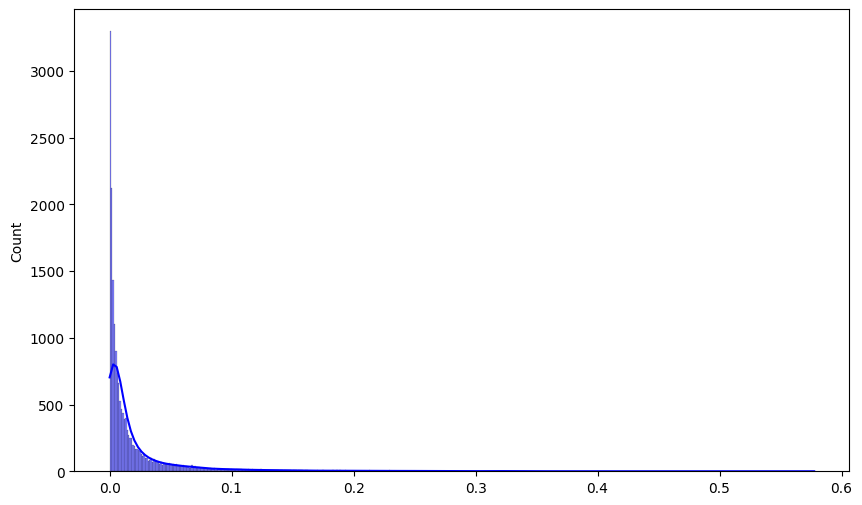

In [1099]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
kde=True
color='blue'
figsize=(10, 6)
bins = 500
  # Flatten the matrix to get all values in a 1D array
values = big_matrix.flatten()

    # Create the figure and axes
plt.figure(figsize=figsize)
    
    # Plot the histogram with kernel density estimate
sns.histplot(values, bins=bins, kde=kde, color=color)

# not consistent with their data.

In [1100]:
out_folder_gamma

'/Users/jeffreyohl/Dropbox/SpatialW25/BigDataFiles/pset2/gamma/'

In [1101]:

# Display the first few rows of each dataframe for verification
print("Value Added Clean:")
print(value_added_clean.head())
print("\nGross Output Clean:")
print(gross_output_clean.head())

# Merge the dataframes
merged_df = pd.merge(
    value_added_clean, 
    gross_output_clean, 
    on=['Country', 'Industry'], 
    suffixes=('_va', '_go')
)

# Create a separate column to identify zero denominators
merged_df['zero_denominator'] = merged_df['Value_go'] == 0

# Calculate the quotient where denominator isn't zero
# Handle division by zero safely
merged_df['quotient'] = np.nan  # Initialize with NaN
# Only calculate for non-zero denominators
non_zero_mask = ~merged_df['zero_denominator']
merged_df.loc[non_zero_mask, 'quotient'] = (
    merged_df.loc[non_zero_mask, 'Value_va'] / 
    merged_df.loc[non_zero_mask, 'Value_go']
)

# Group by industry to calculate the average quotient for each industry
industry_avg_quotients = merged_df.loc[~merged_df['zero_denominator']].groupby('Industry')['quotient'].mean()

# Now handle zero denominators using the calculated averages
for idx, row in merged_df[merged_df['zero_denominator']].iterrows():
    industry = row['Industry']
    # If there's an average for this industry, use it
    if industry in industry_avg_quotients:
        merged_df.at[idx, 'quotient'] = industry_avg_quotients[industry]
    else:
        # If no average is available for this industry (all countries have zero denominator),
        # use the overall average across all industries
        overall_avg = merged_df.loc[~merged_df['zero_denominator'], 'quotient'].mean()
        merged_df.at[idx, 'quotient'] = overall_avg

# Create the pivot table
gamma_matrix = merged_df.pivot_table(
    values='quotient',
    index='Industry',
    columns='Country',
    fill_value=0
)

# Check if the matrix has the desired dimensions (22 industries x countries)
num_industries = 22
if gamma_matrix.shape[0] != num_industries:
    print(f"Adding missing industries to ensure 22 industries in total")
    
    # Ensure all industries from 1 to 22 are included
    all_industries = list(range(1, num_industries + 1))
    missing_industries = set(all_industries) - set(gamma_matrix.index)
    
    if missing_industries:
        print(f"Missing industries: {missing_industries}")
        # Add missing industries with zeros
        for ind in missing_industries:
            gamma_matrix.loc[ind] = 0
    
    # Sort the industries
    gamma_matrix = gamma_matrix.sort_index()

# Define the output path

# Save the gamma matrix to a CSV file
output_file = os.path.join(out_folder_gamma, "gamma_countries.csv")
gamma_matrix.to_csv(output_file,header=False, index=False)

# Create a histogram of the values in gamma_matrix
import matplotlib.pyplot as plt

# Flatten the matrix to get all values
gamma_values = gamma_matrix.values.flatten()

# Remove any zeros which might skew the histogram
gamma_values = gamma_values[gamma_values > 0]



print(f"\nGamma matrix saved to: {output_file}")
print(f"Histogram saved to: {histogram_file}")
print(f"Final matrix dimensions: {gamma_matrix.shape}")
print("\nSummary of zero denominator handling:")
zero_denom_count = merged_df['zero_denominator'].sum()
print(f"- Total zero denominators found: {zero_denom_count}")
print(f"- Number of industries with averages available: {len(industry_avg_quotients)}")
print(f"- Overall average quotient: {merged_df.loc[~merged_df['zero_denominator'], 'quotient'].mean():.4f}")

# Print summary statistics of the gamma values
print("\nSummary statistics of gamma values:")
print(f"- Min: {np.min(gamma_values):.4f}")
print(f"- Max: {np.max(gamma_values):.4f}")
print(f"- Mean: {np.mean(gamma_values):.4f}")
print(f"- Median: {np.median(gamma_values):.4f}")
print(f"- Standard deviation: {np.std(gamma_values):.4f}")

Value Added Clean:
   Country  Industry         Value
0      1.0       1.0  24247.396178
1      1.0       2.0   2335.770879
2      1.0       3.0   8888.678187
3      1.0       4.0   3751.803517
4      1.0       5.0   8693.802956

Gross Output Clean:
   Country  Industry         Value
0      1.0       1.0  83504.036584
1      1.0       2.0   5064.024116
2      1.0       3.0  24709.086562
3      1.0       4.0  24455.020256
4      1.0       5.0  25945.724712

Gamma matrix saved to: /Users/jeffreyohl/Dropbox/SpatialW25/BigDataFiles/pset2/gamma/gamma_countries.csv
Histogram saved to: ./output/gamma_histogram.png
Final matrix dimensions: (22, 38)

Summary of zero denominator handling:
- Total zero denominators found: 1
- Number of industries with averages available: 22
- Overall average quotient: 0.4229

Summary statistics of gamma values:
- Min: 0.0014
- Max: 0.9432
- Mean: 0.4245
- Median: 0.3865
- Standard deviation: 0.1845


/var/folders/g9/ggrmf_5j6tx4rv5qdhs0slq40000gn/T/ipykernel_87551/3034944011.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.29037394082814444 0.461247976982557 0.3597331760890395
 0.15341649599702076 0.3350765127053204 0.3942413239888542
 0.3522827169899784 0.21350913415048506 0.36131242587956264
 0.5215057827500189 0.27210309883977085 0.3795970578829549
 0.5342750433962528 0.3089182164551607 0.44166681368311494
 0.4863855552735579 0.626766761584261 0.700854977653993 0.7521196804174141
 0.7372232218264605 0.46993408076404014 0.5096280922142609
 0.2658712302652908 0.335525700570431 0.2826517711701639
 0.02127392644634053 0.22666343313197235 0.3859866918263981
 0.3831105562829219 0.31452562645082666 0.3649763566929453
 0.4611305335974514 0.27009295318229654 0.3806369347515084
 0.5738753567892121 0.39548197855997275 0.49833225182390994
 0.4457239782703372 0.49920912390145833 0.6687076467957759
 0.81

In [1102]:
gamma_matrix

Country,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,28.0,29.0,30.0,31.0,32.0,33.0,34.0,35.0,36.0,37.0
Industry,,,,,,,,,,,,,,,,,,,,,
1.0,0.252512,0.290374,0.265871,0.194725,0.265996,0.191845,0.287228,0.227718,0.259549,0.244155,...,0.232423,0.208344,0.263659,0.267764,0.161435,0.264176,0.232938,0.225322,0.306681,0.237176
2.0,0.298011,0.461248,0.335526,0.278865,0.376044,0.357624,0.388757,0.199340,0.311900,0.334160,...,0.355056,0.301676,0.394273,0.346967,0.253313,0.375211,0.254932,0.262936,0.505455,0.219989
3.0,0.324489,0.359733,0.282652,0.259963,0.259868,0.326111,0.332020,0.230995,0.363835,0.269367,...,0.355862,0.315267,0.367966,0.302821,0.276097,0.254557,0.256598,0.302458,0.378169,0.257480
4.0,0.207964,0.153416,0.021274,0.026913,-0.044366,-0.088451,0.111369,0.128836,0.192392,0.046715,...,0.293911,0.034052,0.049726,0.250001,0.065972,0.078445,0.095415,0.125490,0.088525,0.118480
5.0,0.444756,0.335077,0.226663,0.289488,0.281609,0.214338,0.354754,0.180906,0.384830,0.246280,...,0.301401,0.242687,0.214292,0.388223,0.214229,0.512322,0.116697,0.277307,0.386586,0.208130
6.0,0.323846,0.394241,0.385987,0.357379,0.217705,0.265051,0.357929,0.187437,0.341229,0.298812,...,0.213634,0.313884,0.308451,0.344312,0.287038,0.347249,0.261339,0.260142,0.419298,0.203092
7.0,0.398787,0.352283,0.383111,0.305496,0.286953,0.335342,0.447731,0.252116,0.311374,0.361965,...,0.347214,0.318342,0.348129,0.357444,0.287038,0.309981,0.283504,0.357962,0.287504,0.268002
8.0,0.311565,0.213509,0.314526,0.204660,0.147784,0.278623,0.413358,0.163026,0.383135,0.283858,...,0.284869,0.230537,0.297251,0.298571,0.247138,0.305360,0.179976,0.249169,0.377685,0.181288
9.0,0.392222,0.361312,0.364976,0.375134,0.336739,0.295207,0.410691,0.220395,0.513325,0.336420,...,0.305367,0.403838,0.309670,0.392615,0.289309,0.381435,0.261271,0.370111,0.391429,0.245530


In [1103]:
gamma_matrix

Country,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,28.0,29.0,30.0,31.0,32.0,33.0,34.0,35.0,36.0,37.0
Industry,,,,,,,,,,,,,,,,,,,,,
1.0,0.252512,0.290374,0.265871,0.194725,0.265996,0.191845,0.287228,0.227718,0.259549,0.244155,...,0.232423,0.208344,0.263659,0.267764,0.161435,0.264176,0.232938,0.225322,0.306681,0.237176
2.0,0.298011,0.461248,0.335526,0.278865,0.376044,0.357624,0.388757,0.199340,0.311900,0.334160,...,0.355056,0.301676,0.394273,0.346967,0.253313,0.375211,0.254932,0.262936,0.505455,0.219989
3.0,0.324489,0.359733,0.282652,0.259963,0.259868,0.326111,0.332020,0.230995,0.363835,0.269367,...,0.355862,0.315267,0.367966,0.302821,0.276097,0.254557,0.256598,0.302458,0.378169,0.257480
4.0,0.207964,0.153416,0.021274,0.026913,-0.044366,-0.088451,0.111369,0.128836,0.192392,0.046715,...,0.293911,0.034052,0.049726,0.250001,0.065972,0.078445,0.095415,0.125490,0.088525,0.118480
5.0,0.444756,0.335077,0.226663,0.289488,0.281609,0.214338,0.354754,0.180906,0.384830,0.246280,...,0.301401,0.242687,0.214292,0.388223,0.214229,0.512322,0.116697,0.277307,0.386586,0.208130
6.0,0.323846,0.394241,0.385987,0.357379,0.217705,0.265051,0.357929,0.187437,0.341229,0.298812,...,0.213634,0.313884,0.308451,0.344312,0.287038,0.347249,0.261339,0.260142,0.419298,0.203092
7.0,0.398787,0.352283,0.383111,0.305496,0.286953,0.335342,0.447731,0.252116,0.311374,0.361965,...,0.347214,0.318342,0.348129,0.357444,0.287038,0.309981,0.283504,0.357962,0.287504,0.268002
8.0,0.311565,0.213509,0.314526,0.204660,0.147784,0.278623,0.413358,0.163026,0.383135,0.283858,...,0.284869,0.230537,0.297251,0.298571,0.247138,0.305360,0.179976,0.249169,0.377685,0.181288
9.0,0.392222,0.361312,0.364976,0.375134,0.336739,0.295207,0.410691,0.220395,0.513325,0.336420,...,0.305367,0.403838,0.309670,0.392615,0.289309,0.381435,0.261271,0.370111,0.391429,0.245530


In [1104]:

# Save the gamma matrix to a CSV file
output_file = os.path.join(out_folder_gamma, "gamma_countries.csv")
gamma_matrix.to_csv(output_file,header=False, index=False)

# Create a histogram of the values in gamma_matrix
import matplotlib.pyplot as plt

# Flatten the matrix to get all values
gamma_values = gamma_matrix.values.flatten()

# Remove any zeros which might skew the histogram
gamma_values = gamma_values[gamma_values > 0]



print(f"\nGamma matrix saved to: {output_file}")
print(f"Histogram saved to: {histogram_file}")
print(f"Final matrix dimensions: {gamma_matrix.shape}")
print("\nSummary of zero denominator handling:")
zero_denom_count = merged_df['zero_denominator'].sum()
print(f"- Total zero denominators found: {zero_denom_count}")
print(f"- Number of industries with averages available: {len(industry_avg_quotients)}")
print(f"- Overall average quotient: {merged_df.loc[~merged_df['zero_denominator'], 'quotient'].mean():.4f}")

# Print summary statistics of the gamma values
print("\nSummary statistics of gamma values:")
print(f"- Min: {np.min(gamma_values):.4f}")
print(f"- Max: {np.max(gamma_values):.4f}")
print(f"- Mean: {np.mean(gamma_values):.4f}")
print(f"- Median: {np.median(gamma_values):.4f}")
print(f"- Standard deviation: {np.std(gamma_values):.4f}")


Gamma matrix saved to: /Users/jeffreyohl/Dropbox/SpatialW25/BigDataFiles/pset2/gamma/gamma_countries.csv
Histogram saved to: ./output/gamma_histogram.png
Final matrix dimensions: (22, 38)

Summary of zero denominator handling:
- Total zero denominators found: 1
- Number of industries with averages available: 22
- Overall average quotient: 0.4229

Summary statistics of gamma values:
- Min: 0.0014
- Max: 0.9432
- Mean: 0.4245
- Median: 0.3865
- Standard deviation: 0.1845


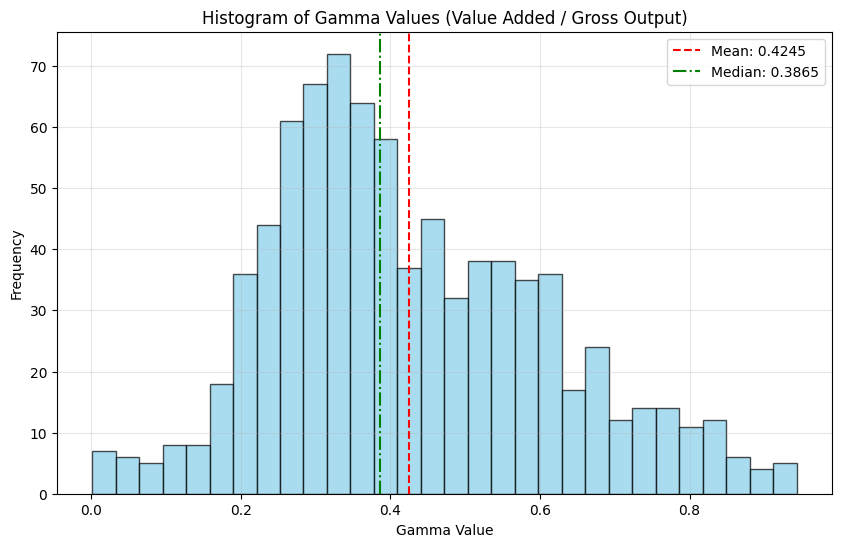

In [1105]:
plt.figure(figsize=(10, 6))
plt.hist(gamma_values, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Histogram of Gamma Values (Value Added / Gross Output)')
plt.xlabel('Gamma Value')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)

# Add summary statistics to the plot
plt.axvline(x=np.mean(gamma_values), color='red', linestyle='--', label=f'Mean: {np.mean(gamma_values):.4f}')
plt.axvline(x=np.median(gamma_values), color='green', linestyle='-.', label=f'Median: {np.median(gamma_values):.4f}')
plt.legend()


plt.show()

In [1106]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [1107]:
value_added_clean

,Country,Industry,Value
0,1.0,1.0,24247.396178
1,1.0,2.0,2335.770879
2,1.0,3.0,8888.678187
3,1.0,4.0,3751.803517
4,1.0,5.0,8693.802956
...,...,...,...
831,0.0,18.0,2058953.0
832,0.0,19.0,192772.0
833,0.0,20.0,1226868.0
834,0.0,21.0,487987.0


In [1108]:
gross_output_clean

,Country,Industry,Value
0,1.0,1.0,83504.036584
1,1.0,2.0,5064.024116
2,1.0,3.0,24709.086562
3,1.0,4.0,24455.020256
4,1.0,5.0,25945.724712
...,...,...,...
831,0.0,18.0,2777993.0
832,0.0,19.0,319912.0
833,0.0,20.0,2087106.0
834,0.0,21.0,892676.0


# Gluing    

In [1109]:
len(sector_matrices)

9

In [1110]:
len(scaled_trade_flows)

13

In [1111]:
df_agg_sector_fix.columns

Index(['ExportingCountry', 'ExportingIndustry', 'ImportingCountry',
       'ImportingIndustry', 'Value'],
      dtype='object')

In [1112]:
# matrix-ise df_agg_sector_fix

In [1113]:
import pandas as pd
import numpy as np

# 1. Filter out rows where ExportingCountry=38 or ImportingCountry=38
df_filtered = df_agg_sector_fix.query(
    "ExportingCountry != 38 & ImportingCountry != 38"
)

intl_sector_matrices = {}

# 2. Loop over each sector
for sector in range(1, 23):
    # 2a. Subset rows for this ExportingIndustry
    df_sector = df_filtered[df_filtered["ExportingIndustry"] == sector]
    
    # 2b. Pivot with aggfunc='sum' so that each (ExportingCountry, ImportingCountry)
    #     collapses into a single Value
    pivoted = df_sector.pivot_table(
        index="ExportingCountry",
        columns="ImportingCountry",
        values="Value",
        aggfunc="sum",
        fill_value=0
    )
    
    # 2c. Reindex to ensure the table is 1..37 × 1..37
    pivoted = pivoted.reindex(index=range(1, 38),
                              columns=range(1, 38),
                              fill_value=0)
    
    # 2d. Convert to NumPy array
    mat = pivoted.to_numpy()
    
    intl_sector_matrices[sector] = mat


# all of the belows are dicts of matrices. where the key is the sector

# Country-Country Trade
#### intl_sector_matrices    -  37x37 non-US trade for each of 22 sectors. sorted

# State-State Trade
#### scaled_trade_flows       -  50x50 for non-service sectors, which we have CFS data on (first 13)
#### sector_matrices - 50x50 for services sectors (14-22) 

# State-Country and Country-State trade
#### country_to_state_sector_matrices - 37 x 50 of countries to states for all 22 sectors, sorted.
#### states_to_country_sector_matrices  50 x 37 of state to country for all 22 sectors, sorted.

In [1114]:
sector_matrices[20][47,]

array([3.26439540e-01, 2.01505889e-03, 2.98228716e-01, 2.82108245e-01,
       2.16014313e+00, 1.18888475e-01, 2.63972715e-01, 1.89415536e-01,
       7.69752497e-01, 1.55764052e+00, 0.00000000e+00, 2.01505889e-03,
       1.63824288e+00, 3.88301848e+00, 8.06023557e-02, 3.54650365e-01,
       5.56559266e+00, 4.05026837e-01, 4.87644252e-01, 5.35199642e+00,
       7.01240494e-01, 4.87442746e+00, 3.58680483e-01, 1.97878783e+00,
       4.51373192e-01, 4.03011778e-03, 2.01505889e-03, 4.03011778e-03,
       1.02768003e-01, 1.95460712e+00, 0.00000000e+00, 3.58075965e+00,
       1.42605718e+01, 2.01505889e-03, 2.13757447e+01, 2.43822126e-01,
       1.00752945e-01, 1.66161756e+01, 2.01505889e-03, 6.95195318e-01,
       0.00000000e+00, 2.05536007e+00, 5.54745713e+00, 2.21656478e-02,
       1.47099299e-01, 6.19832115e+00, 3.12334128e-01, 9.11411137e+01,
       9.45062620e-01, 2.82108245e-02])

In [1115]:
sector_matrices[20][:,47]

array([8.40279558e-01, 0.00000000e+00, 2.21656478e-02, 1.37024005e-01,
       3.78831072e+00, 1.02768003e-01, 2.09566125e-01, 3.42560012e-02,
       1.08208662e+00, 2.75458550e+00, 0.00000000e+00, 1.81355300e-02,
       2.27500149e+00, 2.84324810e+00, 4.27192485e-01, 2.29716714e-01,
       1.87682585e+01, 1.70272476e+00, 1.41054122e-02, 2.86742880e+00,
       9.89393916e-01, 2.05132995e+00, 1.03574027e+00, 2.98228716e-01,
       1.35210452e+00, 1.91430595e-01, 5.84367079e-02, 4.03011778e-02,
       1.08813180e-01, 4.26990979e+00, 0.00000000e+00, 3.52030788e+00,
       5.83762561e+00, 0.00000000e+00, 2.55247510e+01, 9.87378857e-02,
       1.87400477e-01, 3.41975644e+01, 7.45571790e-02, 2.96818175e+00,
       2.61957656e-02, 6.41594751e+00, 6.77865811e+00, 1.61204711e-01,
       9.87378857e-02, 1.26505397e+01, 2.76063068e-01, 9.11411137e+01,
       1.55965558e+00, 2.01505889e-03])

In [1116]:
sector_keys = range(1,23)

In [1117]:
import numpy as np

# Assuming sector_keys is a list of the sector keys in the correct order
final_matrix_list = []

for i, key in enumerate(sector_keys):
    print(key)
    # Select the appropriate state-to-state matrix based on the sector type
    if i < 13:  # sectors 1 to 13: non-services
        state_state = scaled_trade_flows[key]  # shape (50,50)
    else:       # sectors 14 to 22: services
        state_state = sector_matrices[key]     # shape (50,50)
    
    # Retrieve the state-to-country, country-to-state, and country-to-country matrices
    state_country   = states_to_country_sector_matrices[key]   # shape (50,37)
    country_state   = country_to_state_sector_matrices[key]      # shape (37,50)
    country_country = intl_sector_matrices[key]                # shape (37,37)
    
    # Create the 87x87 matrix for the current sector
    sector_matrix = np.block([
        [state_state,   state_country],
        [country_state, country_country]
    ])
    # Find rows with zero sums in final_matrix
    import numpy as np

    # Calculate the sum of each row
    row_sums = np.sum(sector_matrix, axis=1)

    # Find indices where the sum is zero (or very close to zero due to floating point precision)
    zero_sum_indices = np.where(np.isclose(row_sums, 0, atol=1e-10))[0]

    # Print the indices of rows with zero sums
    print("Indices of rows with zero sums:")
    print(zero_sum_indices)

    # Print the number of zero-sum rows found
    print(f"Found {len(zero_sum_indices)} rows with zero sums")

    # Optionally, examine a few of these rows to verify
    if len(zero_sum_indices) > 0:
        print("\nSample of rows with zero sums:")
        for idx in zero_sum_indices[:5]:  # Show up to 5 examples
            print(f"Row {idx}: Sum = {row_sums[idx]}")
            print(final_matrix[idx, :10])  # Show first 10 elements of the row        
    final_matrix_list.append(sector_matrix)

# Vertically stack all 22 sector matrices to form the final 1914x87 matrix
final_matrix = np.vstack(final_matrix_list)


1
Indices of rows with zero sums:
[]
Found 0 rows with zero sums
2
Indices of rows with zero sums:
[]
Found 0 rows with zero sums
3
Indices of rows with zero sums:
[]
Found 0 rows with zero sums
4
Indices of rows with zero sums:
[]
Found 0 rows with zero sums
5
Indices of rows with zero sums:
[]
Found 0 rows with zero sums
6
Indices of rows with zero sums:
[]
Found 0 rows with zero sums
7
Indices of rows with zero sums:
[]
Found 0 rows with zero sums
8
Indices of rows with zero sums:
[]
Found 0 rows with zero sums
9
Indices of rows with zero sums:
[]
Found 0 rows with zero sums
10
Indices of rows with zero sums:
[]
Found 0 rows with zero sums
11
Indices of rows with zero sums:
[]
Found 0 rows with zero sums
12
Indices of rows with zero sums:
[]
Found 0 rows with zero sums
13
Indices of rows with zero sums:
[]
Found 0 rows with zero sums
14
Indices of rows with zero sums:
[]
Found 0 rows with zero sums
15
Indices of rows with zero sums:
[]
Found 0 rows with zero sums
16
Indices of rows 

In [1118]:
final_matrix.shape

(1914, 87)

In [1119]:
min(df)

0

In [1120]:
df = pd.DataFrame(final_matrix)
df = df.clip(lower=0)  # This replaces all negative values with 0

# Save to CSV
df.to_csv(out_folder + "X_in_j.csv",
          index=False,  # Set to True if you want row indices
          header=False)
df.to_csv(out_folder + "X_in_j.txt",
          index=False,  # Set to True if you want row indices
          header=False)

In [1121]:
scaled_trade_flows

{np.float64(1.0): array([[1.52894226e+03, 0.00000000e+00, 4.52431524e+01, ...,
         3.79904333e+00, 3.21191845e+01, 0.00000000e+00],
        [0.00000000e+00, 6.97987870e+02, 2.41757303e+00, ...,
         0.00000000e+00, 6.90735151e-01, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 2.94356785e+03, ...,
         0.00000000e+00, 4.66246227e+01, 0.00000000e+00],
        ...,
        [1.38147030e+00, 0.00000000e+00, 0.00000000e+00, ...,
         1.50234895e+02, 3.45367575e-01, 0.00000000e+00],
        [5.49134445e+01, 0.00000000e+00, 6.66559421e+01, ...,
         0.00000000e+00, 6.51363247e+03, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 3.45367575e-01, ...,
         0.00000000e+00, 0.00000000e+00, 9.84297590e+01]], shape=(50, 50)),
 np.float64(2.0): array([[167.2716064 ,   0.        ,  19.470769  , ...,   0.        ,
          30.97622341,   0.        ],
        [  0.        ,   7.96531459,   0.        , ...,   0.        ,
           0.        ,   0.        ],

In [1122]:
sector_matrices

{np.float64(14.0): array([[1.61044663e+03, 2.21676006e-02, 1.30936628e+01, ...,
         3.08129649e+00, 1.93301478e+01, 3.17735609e-01],
        [0.00000000e+00, 2.33476559e+02, 5.17244015e-02, ...,
         0.00000000e+00, 1.47784004e-02, 0.00000000e+00],
        [8.22417984e+00, 2.88178808e-01, 1.51018996e+03, ...,
         8.12812023e-02, 9.78330108e+00, 1.85468925e+00],
        ...,
        [1.19705043e+00, 7.38920021e-03, 1.09360163e+00, ...,
         3.34213526e+02, 3.46553490e+00, 1.03448803e-01],
        [2.32316455e+01, 5.46800816e-01, 2.28547963e+01, ...,
         5.71924096e+00, 2.04646856e+03, 1.26355324e+00],
        [5.91136017e-02, 7.38920021e-03, 1.07882323e+00, ...,
         7.38920021e-03, 6.57638819e-01, 1.54338225e+02]], shape=(50, 50)),
 np.float64(15.0): array([[4.34792782e+03, 5.98486940e-02, 3.53506286e+01, ...,
         8.31896847e+00, 5.21880612e+01, 8.57831281e-01],
        [0.00000000e+00, 6.30346395e+02, 1.39646953e-01, ...,
         0.00000000e+00, 3.9899

In [1123]:
states_to_country_sector_matrices

{1:                        1         2          3         4          5   \
 Alabama          3.695095  0.454513   3.409513  0.027221   5.094353   
 Alaska           0.924837  0.113759   0.853359  0.006813   1.275054   
 Arizona          2.987255  0.367446   2.756380  0.022007   4.118469   
 Arkansas         7.569865  0.931128   6.984816  0.055766  10.436421   
 California      32.461399  3.992899  29.952568  0.239138  44.753880   
 Colorado         3.710684  0.456431   3.423898  0.027336   5.115846   
 Connecticut      2.039743  0.250898   1.882098  0.015026   2.812152   
 Delaware         0.921530  0.113352   0.850308  0.006789   1.270494   
 Florida          8.700833  1.070242   8.028375  0.064098  11.995664   
 Georgia          9.032943  1.111093   8.334817  0.066544  12.453537   
 Hawaii           0.873343  0.107425   0.805845  0.006434   1.204060   
 Idaho            3.371646  0.414728   3.111063  0.024838   4.648421   
 Illinois        15.525539  1.909712  14.325622  0.114374  21

In [1124]:
country_to_state_sector_matrices

{np.float64(1.0):       Alabama     Alaska    Arizona    Arkansas  California   Colorado  \
 1    3.494046   0.874517   2.824720    7.157992   30.695188   3.508788   
 2    0.390214   0.097666   0.315464    0.799403    3.428031   0.391860   
 3    1.626140   0.407003   1.314633    3.331351   14.285635   1.633001   
 4    0.057466   0.014383   0.046458    0.117727    0.504841   0.057709   
 5    7.110770   1.779738   5.748617   14.567303   62.468096   7.140770   
 6   45.349637  11.350454  36.662371   92.904419  398.396463  45.540968   
 7   11.687413   2.925215   9.448549   23.943131  102.673896  11.736722   
 8    0.001836   0.000460   0.001485    0.003762    0.016133   0.001844   
 9    0.277740   0.069515   0.224535    0.568985    2.439942   0.278911   
 10   0.885357   0.221594   0.715756    1.813765    7.777861   0.889093   
 11   0.047392   0.011862   0.038313    0.097088    0.416335   0.047591   
 12   0.179665   0.044968   0.145248    0.368067    1.578359   0.180423   
 13   1.

# Gross Output   - already calc'd at the Country Level.

In [1125]:
# Initialize the output matrix (50x22)
gross_output_states = np.zeros((50, 22))
    
    # Process each of the 22 submatrices
for j in range(22):
        # Extract the j-th submatrix (87x87)
    start_row = j * 87
    end_row = (j + 1) * 87
    submatrix = final_matrix[start_row:end_row, :]
        
        # Calculate rowsums for this submatrix
    rowsums = np.sum(submatrix, axis=1)  # Shape: (87,)
        
        # Take the first 50 rowsums and store them in the output matrix
    gross_output_states[:, j] = rowsums[:50]

In [1126]:
gross_output_states

array([[4.83948218e+03, 1.56866489e+03, 1.09550292e+04, ...,
        9.64633310e+02, 3.08190756e+03, 4.58768526e+04],
       [1.39894940e+03, 7.96531459e+00, 1.24226167e+02, ...,
        7.53374176e+01, 2.34754216e+02, 3.60475921e+03],
       [4.44009308e+03, 2.65132953e+02, 2.43113849e+03, ...,
        7.25760743e+02, 2.28512779e+03, 3.56081323e+04],
       ...,
       [4.79724189e+02, 2.48938304e+01, 1.41705974e+03, ...,
        2.05300189e+02, 6.45404213e+02, 9.70162888e+03],
       [1.75809758e+04, 8.39165702e+02, 2.10629310e+04, ...,
        1.29449155e+03, 4.12895658e+03, 6.13907701e+04],
       [1.77487792e+02, 1.70527801e+01, 8.11569109e+01, ...,
        6.08465098e+01, 1.91951346e+02, 2.93688263e+03]], shape=(50, 22))

# Value-added. States. 

In [1127]:
gamma_matrix

Country,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,28.0,29.0,30.0,31.0,32.0,33.0,34.0,35.0,36.0,37.0
Industry,,,,,,,,,,,,,,,,,,,,,
1.0,0.252512,0.290374,0.265871,0.194725,0.265996,0.191845,0.287228,0.227718,0.259549,0.244155,...,0.232423,0.208344,0.263659,0.267764,0.161435,0.264176,0.232938,0.225322,0.306681,0.237176
2.0,0.298011,0.461248,0.335526,0.278865,0.376044,0.357624,0.388757,0.199340,0.311900,0.334160,...,0.355056,0.301676,0.394273,0.346967,0.253313,0.375211,0.254932,0.262936,0.505455,0.219989
3.0,0.324489,0.359733,0.282652,0.259963,0.259868,0.326111,0.332020,0.230995,0.363835,0.269367,...,0.355862,0.315267,0.367966,0.302821,0.276097,0.254557,0.256598,0.302458,0.378169,0.257480
4.0,0.207964,0.153416,0.021274,0.026913,-0.044366,-0.088451,0.111369,0.128836,0.192392,0.046715,...,0.293911,0.034052,0.049726,0.250001,0.065972,0.078445,0.095415,0.125490,0.088525,0.118480
5.0,0.444756,0.335077,0.226663,0.289488,0.281609,0.214338,0.354754,0.180906,0.384830,0.246280,...,0.301401,0.242687,0.214292,0.388223,0.214229,0.512322,0.116697,0.277307,0.386586,0.208130
6.0,0.323846,0.394241,0.385987,0.357379,0.217705,0.265051,0.357929,0.187437,0.341229,0.298812,...,0.213634,0.313884,0.308451,0.344312,0.287038,0.347249,0.261339,0.260142,0.419298,0.203092
7.0,0.398787,0.352283,0.383111,0.305496,0.286953,0.335342,0.447731,0.252116,0.311374,0.361965,...,0.347214,0.318342,0.348129,0.357444,0.287038,0.309981,0.283504,0.357962,0.287504,0.268002
8.0,0.311565,0.213509,0.314526,0.204660,0.147784,0.278623,0.413358,0.163026,0.383135,0.283858,...,0.284869,0.230537,0.297251,0.298571,0.247138,0.305360,0.179976,0.249169,0.377685,0.181288
9.0,0.392222,0.361312,0.364976,0.375134,0.336739,0.295207,0.410691,0.220395,0.513325,0.336420,...,0.305367,0.403838,0.309670,0.392615,0.289309,0.381435,0.261271,0.370111,0.391429,0.245530


In [1128]:
gross_output_states

array([[4.83948218e+03, 1.56866489e+03, 1.09550292e+04, ...,
        9.64633310e+02, 3.08190756e+03, 4.58768526e+04],
       [1.39894940e+03, 7.96531459e+00, 1.24226167e+02, ...,
        7.53374176e+01, 2.34754216e+02, 3.60475921e+03],
       [4.44009308e+03, 2.65132953e+02, 2.43113849e+03, ...,
        7.25760743e+02, 2.28512779e+03, 3.56081323e+04],
       ...,
       [4.79724189e+02, 2.48938304e+01, 1.41705974e+03, ...,
        2.05300189e+02, 6.45404213e+02, 9.70162888e+03],
       [1.75809758e+04, 8.39165702e+02, 2.10629310e+04, ...,
        1.29449155e+03, 4.12895658e+03, 6.13907701e+04],
       [1.77487792e+02, 1.70527801e+01, 8.11569109e+01, ...,
        6.08465098e+01, 1.91951346e+02, 2.93688263e+03]], shape=(50, 22))

In [1129]:
import pandas as pd
import numpy as np
import os
states = list(states_to_country_sector_matrices[2].index)
# File paths
gdp_path = "/Users/jeffreyohl/Dropbox/SpatialW25/BigDataFiles/pset2/BEA_Value_added/GDP_Sector_State_2016.xlsx"
tax_path = "/Users/jeffreyohl/Dropbox/SpatialW25/BigDataFiles/pset2/BEA_Value_added/Tax_Subsidies_Sector_Sate_2016.csv"
codes_path = "/Users/jeffreyohl/Dropbox/SpatialW25/BigDataFiles/pset2/BEA_Value_added/Codes.xlsx"

# 1. Read in the data files
gdp_data = pd.read_excel(gdp_path)
tax_data = pd.read_csv(tax_path)
codes_data = pd.read_excel(codes_path)

# Load gamma_matrix
# Convert to DataFrame for easier handling
gamma_matrix_np = pd.DataFrame(gamma_matrix.values)

# 2. Process and clean the data
codes_data = codes_data.dropna(subset=['LineCode'])
gdp_data = gdp_data.dropna(subset=['LineCode'])

gdp_data = gdp_data[gdp_data['2016'] != "(L)"]
if 'LineCode' in tax_data.columns:
    tax_data = tax_data.dropna(subset=['LineCode'])

# Extract the CDP code from the codes file
codes_data = codes_data.rename(columns={
    'BEA Codes (BEA 2016)': 'Description',
    'LineCode': 'LineCode',
    'NAICS ': 'NAICS',  # Note the space in 'NAICS '
    'CDP': 'CDP'
})

# Clean up data
codes_data = codes_data.dropna(subset=['LineCode'])
codes_data['LineCode'] = codes_data['LineCode'].astype(int)
gdp_data['LineCode'] = gdp_data['LineCode'].astype(int)

# Make sure tax_data has the right format
if 'LineCode' in tax_data.columns:
    tax_data['LineCode'] = tax_data['LineCode'].astype(int)

# 3. Create a mapping between LineCode and CDP sector
# This maps BEA LineCode to CDP sector number
# We'll only consider CDP sectors 1-12 as requested
cdp_sectors_in_codes = set()
line_to_cdp_map = {}

if 'CDP' in codes_data.columns:
    for _, row in codes_data.iterrows():
        if not pd.isna(row['CDP']):
            cdp_sector = int(row['CDP'])
            # Only map sectors 1-12
            if 1 <= cdp_sector <= 12:
                line_to_cdp_map[row['LineCode']] = cdp_sector
                cdp_sectors_in_codes.add(cdp_sector)
else:
    # If no CDP column, we'll just use LineCode that matches industries in gamma_matrix
    # This is a fallback but based on your instruction, we should have a CDP column
    for _, row in codes_data.iterrows():
        if row['LineCode'] in industries:
            line_to_cdp_map[row['LineCode']] = row['LineCode']
            cdp_sectors_in_codes.add(row['LineCode'])

# 4. Combine District of Columbia with Virginia in both GDP and tax data
# First, identify all the states in the data
all_states_gdp = gdp_data['GeoName'].unique()
all_states_tax = tax_data['GeoName'].unique() if 'GeoName' in tax_data.columns else []

# Combine DC and Virginia in GDP data
virginia_mask = gdp_data['GeoName'] == 'Virginia *'
dc_mask = gdp_data['GeoName'] == 'District of Columbia *'

if any(dc_mask) and any(virginia_mask):
    # Group by LineCode and sum the values
    dc_data = gdp_data[dc_mask].copy()
    virginia_data = gdp_data[virginia_mask].copy()
    
    # Combine the data - group by LineCode and sum the 2016 values
    combined_values = pd.concat([dc_data, virginia_data]).groupby('LineCode')['2016'].sum().reset_index()
    
    # Update the Virginia entries with the combined values
    for _, row in combined_values.iterrows():
        gdp_data.loc[(gdp_data['GeoName'] == 'Virginia *') & (gdp_data['LineCode'] == row['LineCode']), '2016'] = row['2016']
    
    # Remove DC entries
    gdp_data = gdp_data[~dc_mask]

# Combine DC and Virginia in tax data if needed
if 'GeoName' in tax_data.columns:
    virginia_mask_tax = tax_data['GeoName'] == 'Virginia *'
    dc_mask_tax = tax_data['GeoName'] == 'District of Columbia *'
    
    if any(dc_mask_tax) and any(virginia_mask_tax):
        # Group by LineCode and sum the values
        dc_tax_data = tax_data[dc_mask_tax].copy()
        virginia_tax_data = tax_data[virginia_mask_tax].copy()
        
        # Combine the data - group by LineCode and sum the 2016 values
        combined_tax_values = pd.concat([dc_tax_data, virginia_tax_data]).groupby('LineCode')['2016'].sum().reset_index()
        
        # Update the Virginia entries with the combined values
        for _, row in combined_tax_values.iterrows():
            tax_data.loc[(tax_data['GeoName'] == 'Virginia *') & (tax_data['LineCode'] == row['LineCode']), '2016'] = row['2016']
        
        # Remove DC entries
        tax_data = tax_data[~dc_mask_tax]

# Create a mapping dictionary from state names in the data to state names in the 'states' list
# First, clean the state names to remove asterisks and whitespace
clean_state_map = {}
for state_name in gdp_data['GeoName'].unique():
    clean_name = state_name.replace('*', '').strip()
    clean_state_map[state_name] = clean_name

# 5. Calculate value-added for each state-sector pair (only for CDP sectors 1-12)
# Value added = GDP - (taxes/subsidies)
# Use the provided states list - these are the states we want in our final output

# Create dictionaries to store values for each state and sector
value_added_dict = {state: {j+1: 0 for j in range(12)} for state in states}

# Process each unique state in GDP data
for original_state_name in gdp_data['GeoName'].unique():
    clean_state_name = clean_state_map[original_state_name]
    
    # Skip if this state isn't in our target states list
    if clean_state_name not in states:
        continue
    
    # Get GDP data for this state
    state_gdp = gdp_data[gdp_data['GeoName'] == original_state_name]
    
    # Get tax/subsidies data for this state
    state_tax = tax_data[tax_data['GeoName'] == original_state_name] if ('GeoName' in tax_data.columns) else pd.DataFrame()
    
    # For each BEA LineCode that maps to a CDP sector
    for line_code, cdp_sector in line_to_cdp_map.items():
        # Get GDP value
        gdp_value = state_gdp[state_gdp['LineCode'] == line_code]['2016'].values
        if len(gdp_value) > 0:
            gdp_value = gdp_value[0]
        else:
            continue
            
        # Get tax/subsidies value
        tax_value = 0
        if not state_tax.empty and 'LineCode' in state_tax.columns:
            tax_values = state_tax[state_tax['LineCode'] == line_code]['2016'].values
            if len(tax_values) > 0:
                tax_value = tax_values[0]
                
        # Calculate value-added (in millions of dollars to match WIOD - diff. units)
        value_added = gdp_value - tax_value/1000
        
        # Store in our dictionary
        value_added_dict[clean_state_name][cdp_sector] = value_added

# Convert the dictionary to a numpy array in the correct order
value_added_matrix = np.zeros((len(states), 12))
for i, state in enumerate(states):
    for j in range(12):
        value_added_matrix[i, j] = value_added_dict[state][j+1]

# 6. Calculate final ratios with gross_output_states (only for CDP sectors 1-12)
# Initialize ratio matrix for all 22 sectors
ratio_matrix = np.zeros((len(states), 22))

# Fill sectors 1-12 using our calculations
for i, state in enumerate(states):
    for j in range(12):
        if gross_output_states[i, j] > 0:
            ratio_matrix[i, j] = value_added_matrix[i, j] / gross_output_states[i, j]

# 7. Fill sectors 13-22 with values from gamma_matrix
# Use gamma_matrix for sectors 13-22 for all states
for j in range(12, 22):
    cdp_sector = j + 1  # Convert to 1-indexed CDP sector
    
    # Get the value from gamma_matrix for this industry/CDP sector
    if cdp_sector in gamma_matrix_np.columns:
        gamma_value = gamma_matrix_np[cdp_sector].get(0.0, 0)
    else:
        # If not in gamma_matrix columns, try to get a default value or set to 0
        gamma_value = 0
        
    # Apply this value to all states for this sector
    ratio_matrix[:, j] = gamma_value

# 8. Final sweep to replace any value-added ratios > 1 with gamma_matrix values
# Check each element of the ratio_matrix, if > 1, replace with corresponding value from gamma_matrix
for i in range(ratio_matrix.shape[0]):
    for j in range(ratio_matrix.shape[1]):
        cdp_sector = j + 1  # Convert to 1-indexed CDP sector
        
        # If ratio > 1, replace with value from gamma_matrix
        if ratio_matrix[i, j] > 1:
            if cdp_sector in gamma_matrix_np.columns:
                gamma_value = gamma_matrix_np[cdp_sector].get(0.0, 0)
                ratio_matrix[i, j] = gamma_value
            else:
                # If not found in gamma_matrix, cap at 1
                ratio_matrix[i, j] = 1

# Convert the final ratio matrix to a DataFrame for better readability
cdp_sector_names = [f"CDP_{i+1}" for i in range(22)]
final_ratios_df = pd.DataFrame(ratio_matrix, index=states, columns=cdp_sector_names)

# Print the first few rows to verify
print("\nFinal Value-Added to Gross Output Ratios (first 5 rows, first 5 columns):")
print(final_ratios_df.iloc[:5, :5])

# Print dimensions to confirm we have a 50x22 matrix
print(f"\nFinal matrix dimensions: {final_ratios_df.shape}")

# Print number of values that were > 1 and had to be replaced
original_ratios = np.zeros((len(states), 22))
for i, state in enumerate(states):
    for j in range(12):  # Only check sectors 1-12 since others came directly from gamma_matrix
        if gross_output_states[i, j] > 0:
            original_ratios[i, j] = value_added_matrix[i, j] / gross_output_states[i, j]

num_replaced = np.sum(original_ratios > 1)
print(f"\nNumber of ratios > 1 that were replaced with gamma_matrix values: {num_replaced}")

# Save the results (optional)
# final_ratios_df.to_csv("value_added_to_gross_output_ratios.csv")


Final Value-Added to Gross Output Ratios (first 5 rows, first 5 columns):
               CDP_1     CDP_2     CDP_3     CDP_4     CDP_5
Alabama     0.500408  0.066118  0.019431  0.156865  0.417508
Alaska      0.591494  0.223343  0.180695  0.192023  0.293053
Arizona     0.436768  0.114954  0.201052  0.124763  0.330060
Arkansas    0.555862  0.333426  0.046136  0.224614  0.352556
California  0.551452  0.414700  0.161075  0.176984  0.191845

Final matrix dimensions: (50, 22)

Number of ratios > 1 that were replaced with gamma_matrix values: 43


Value-Added to Gross Output Ratios Statistics:
Min: 0.006
Max: 0.980
Mean: 0.330
Median: 0.297
Std Dev: 0.183

Distribution of ratios:
Below 0.3: 56.5%
Between 0.3-0.6: 33.4%
Between 0.6-0.9: 8.9%
Above 0.9: 1.3%


/var/folders/g9/ggrmf_5j6tx4rv5qdhs0slq40000gn/T/ipykernel_87551/1513469343.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(sector_data, labels=[f"S{i+1}" for i in range(len(sector_labels))],


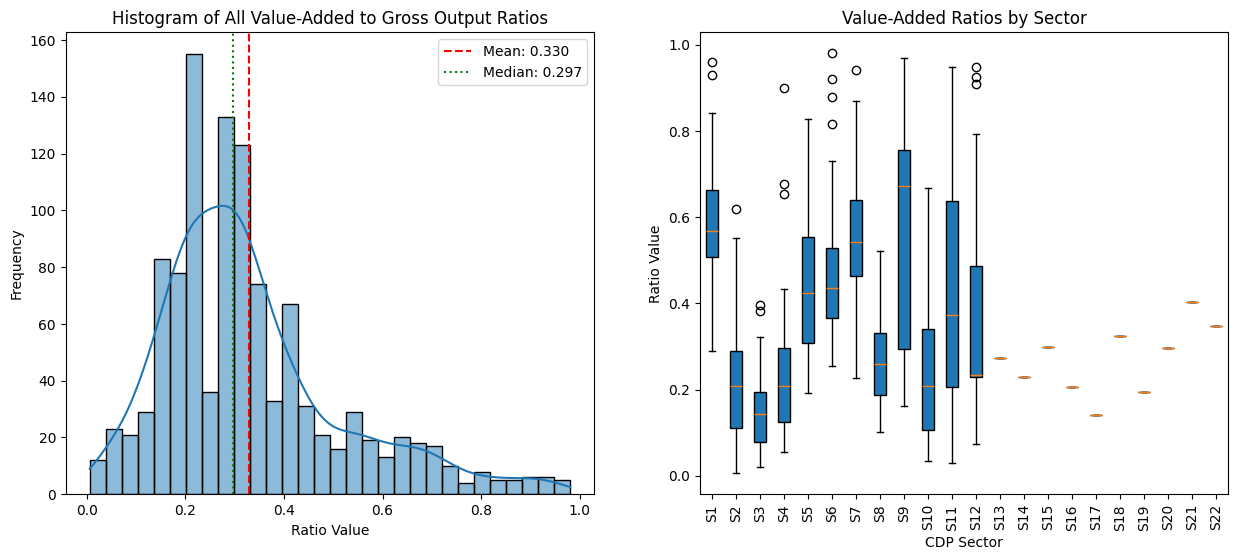

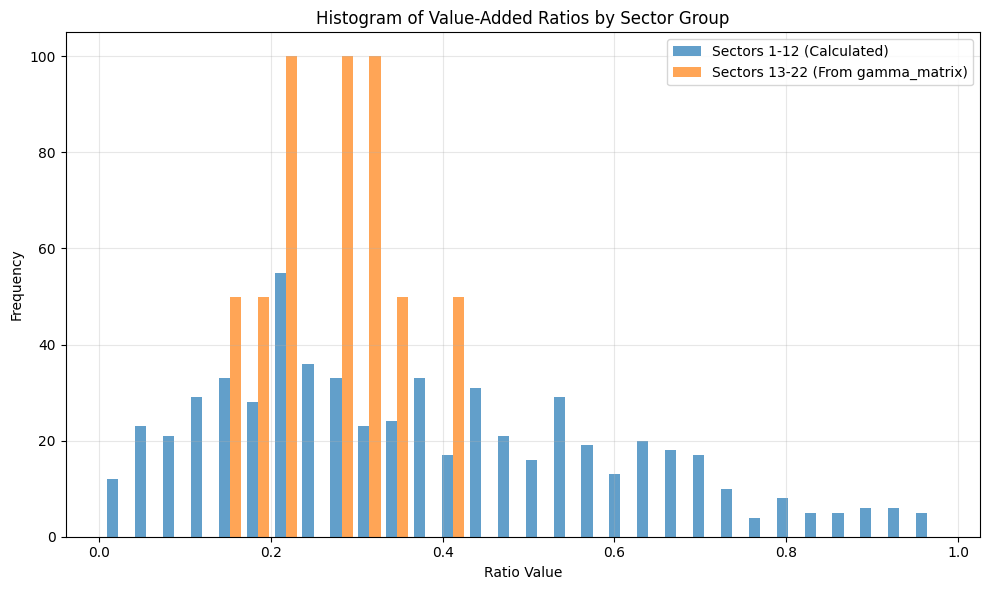

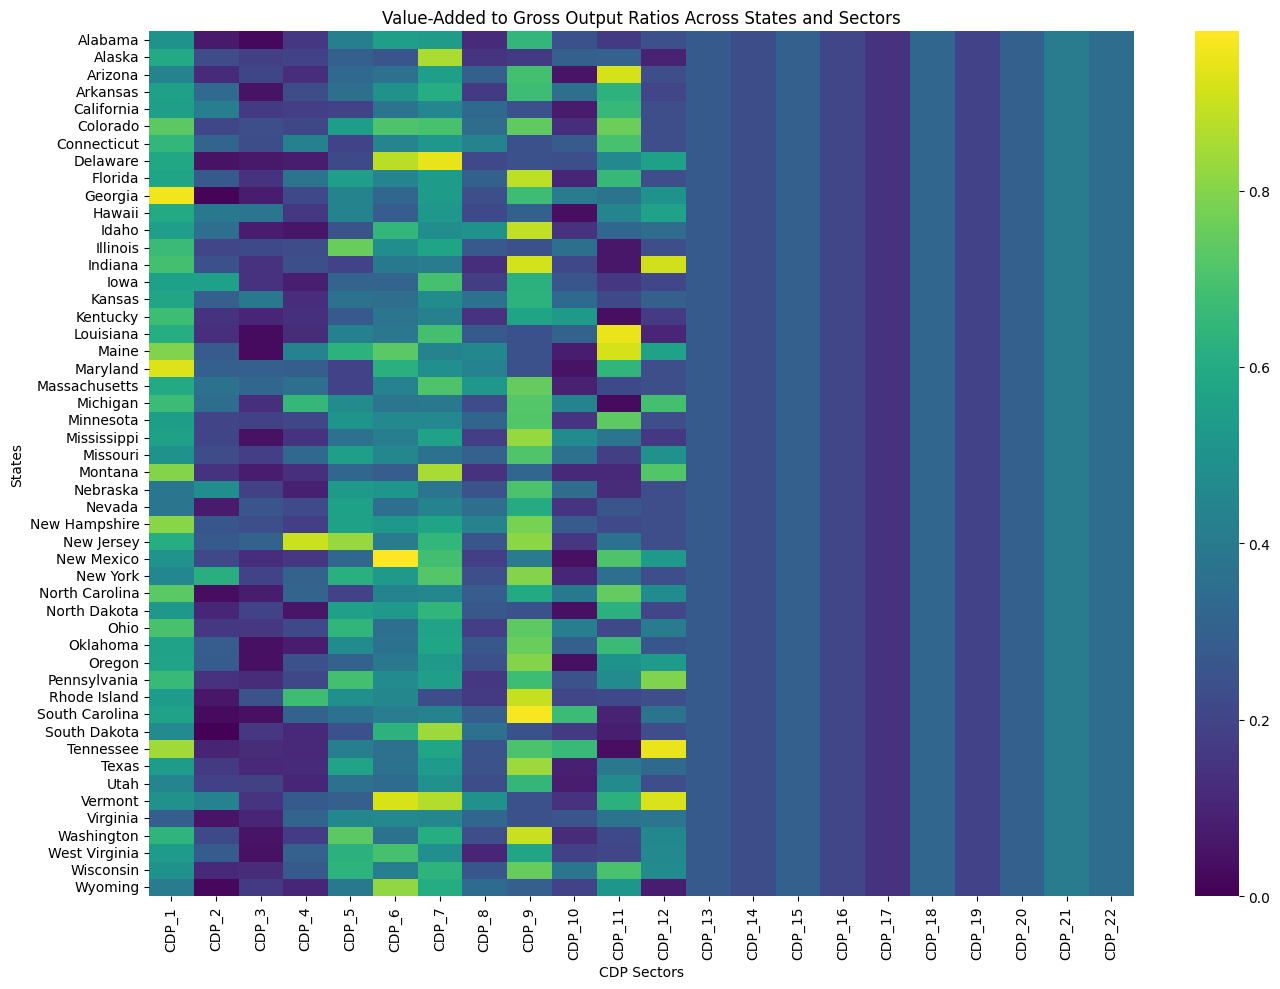

In [1130]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Assuming final_ratios_df is already calculated from the previous code
# If you're running this separately, you'll need to load it:
# final_ratios_df = pd.read_csv("value_added_to_gross_output_ratios.csv", index_col=0)

# Convert the DataFrame to a flattened numpy array for the histogram
ratio_values = final_ratios_df.values.flatten()

# Remove any potential NaN values
ratio_values = ratio_values[~np.isnan(ratio_values)]

# Create figure and axis for the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Overall histogram of all value-added ratios
sns.histplot(ratio_values, bins=30, kde=True, ax=ax1)
ax1.set_title('Histogram of All Value-Added to Gross Output Ratios')
ax1.set_xlabel('Ratio Value')
ax1.set_ylabel('Frequency')
ax1.axvline(x=np.mean(ratio_values), color='red', linestyle='--', 
           label=f'Mean: {np.mean(ratio_values):.3f}')
ax1.axvline(x=np.median(ratio_values), color='green', linestyle=':', 
           label=f'Median: {np.median(ratio_values):.3f}')
ax1.legend()

# Plot 2: Boxplot by sector
sector_data = []
sector_labels = []
for col in final_ratios_df.columns:
    sector_data.append(final_ratios_df[col].values)
    sector_labels.append(col)

ax2.boxplot(sector_data, labels=[f"S{i+1}" for i in range(len(sector_labels))], 
           vert=True, patch_artist=True)
ax2.set_title('Value-Added Ratios by Sector')
ax2.set_xlabel('CDP Sector')
ax2.set_ylabel('Ratio Value')
ax2.set_xticklabels([f"S{i+1}" for i in range(len(sector_labels))], rotation=90)

# Add some statistics
print("Value-Added to Gross Output Ratios Statistics:")
print(f"Min: {np.min(ratio_values):.3f}")
print(f"Max: {np.max(ratio_values):.3f}")
print(f"Mean: {np.mean(ratio_values):.3f}")
print(f"Median: {np.median(ratio_values):.3f}")
print(f"Std Dev: {np.std(ratio_values):.3f}")

# Calculate percentages of values in different ranges
below_0_3 = np.sum(ratio_values < 0.3) / len(ratio_values) * 100
between_0_3_0_6 = np.sum((ratio_values >= 0.3) & (ratio_values < 0.6)) / len(ratio_values) * 100
between_0_6_0_9 = np.sum((ratio_values >= 0.6) & (ratio_values < 0.9)) / len(ratio_values) * 100
above_0_9 = np.sum(ratio_values >= 0.9) / len(ratio_values) * 100

print("\nDistribution of ratios:")
print(f"Below 0.3: {below_0_3:.1f}%")
print(f"Between 0.3-0.6: {between_0_3_0_6:.1f}%")
print(f"Between 0.6-0.9: {between_0_6_0_9:.1f}%")
print(f"Above 0.9: {above_0_9:.1f}%")

# Also create a histogram by sector type (1-12 vs 13-22)
sectors_1_12 = final_ratios_df.iloc[:, :12].values.flatten()
sectors_13_22 = final_ratios_df.iloc[:, 12:].values.flatten()

sectors_1_12 = sectors_1_12[~np.isnan(sectors_1_12)]
sectors_13_22 = sectors_13_22[~np.isnan(sectors_13_22)]

plt.figure(figsize=(10, 6))
plt.hist([sectors_1_12, sectors_13_22], bins=30, 
         label=['Sectors 1-12 (Calculated)', 'Sectors 13-22 (From gamma_matrix)'],
         alpha=0.7)
plt.title('Histogram of Value-Added Ratios by Sector Group')
plt.xlabel('Ratio Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)

# Adjust layout and display
plt.tight_layout()
plt.show()

# You could also create a heatmap to visualize state-sector patterns
plt.figure(figsize=(14, 10))
sns.heatmap(final_ratios_df, cmap='viridis', 
           vmin=0, vmax=min(1, final_ratios_df.values.max()))
plt.title('Value-Added to Gross Output Ratios Across States and Sectors')
plt.xlabel('CDP Sectors')
plt.ylabel('States')
plt.tight_layout()
plt.show()

In [1131]:
final_ratios_df.shape

(50, 22)

In [1132]:
gamma_matrix_np.shape

(22, 38)

In [1133]:
gross_output_clean

,Country,Industry,Value
0,1.0,1.0,83504.036584
1,1.0,2.0,5064.024116
2,1.0,3.0,24709.086562
3,1.0,4.0,24455.020256
4,1.0,5.0,25945.724712
...,...,...,...
831,0.0,18.0,2777993.0
832,0.0,19.0,319912.0
833,0.0,20.0,2087106.0
834,0.0,21.0,892676.0


In [1134]:
gross_output_states

array([[4.83948218e+03, 1.56866489e+03, 1.09550292e+04, ...,
        9.64633310e+02, 3.08190756e+03, 4.58768526e+04],
       [1.39894940e+03, 7.96531459e+00, 1.24226167e+02, ...,
        7.53374176e+01, 2.34754216e+02, 3.60475921e+03],
       [4.44009308e+03, 2.65132953e+02, 2.43113849e+03, ...,
        7.25760743e+02, 2.28512779e+03, 3.56081323e+04],
       ...,
       [4.79724189e+02, 2.48938304e+01, 1.41705974e+03, ...,
        2.05300189e+02, 6.45404213e+02, 9.70162888e+03],
       [1.75809758e+04, 8.39165702e+02, 2.10629310e+04, ...,
        1.29449155e+03, 4.12895658e+03, 6.13907701e+04],
       [1.77487792e+02, 1.70527801e+01, 8.11569109e+01, ...,
        6.08465098e+01, 1.91951346e+02, 2.93688263e+03]], shape=(50, 22))

In [1135]:
gamma_matrix_np = gamma_matrix_np.to_numpy()

# Trying to make value-added (gamma.mat $\gamma$)

In [1136]:
import numpy as np
import pandas as pd

# Load your existing data
# gamma_matrix_np: shape (22, 38)
# finalratios_df: shape (50, 22)

# Step 1: Transpose finalratios_df to get shape (22, 50)
# Assuming the first column might be state names
# If the first column contains state names, use:
# finalratios_numeric = finalratios_df.iloc[:, 1:].copy()
# Otherwise, use the entire dataframe
finalratios_transposed = final_ratios_df.T  # This will transpose to (22, 50)
states_value_adds = finalratios_transposed.values

gamma_matrix_reduced = gamma_matrix_np[:, 1:]
result_matrix = np.hstack((states_value_adds, gamma_matrix_reduced))

In [1137]:
output_path = os.path.join(out_folder_gamma, "gamma.txt")

# Save the result_matrix to CSV
# Despite what the readme says, we actually want a 87x22.
np.savetxt(output_path, result_matrix.T, delimiter=',', fmt='%.10f')

In [1138]:
import numpy as np
import pandas as pd

def diagnose_nan_inf_values(result_matrix):
    """
    Diagnoses NaN and Inf values in a matrix and provides detailed information about their locations.
    
    Parameters:
    result_matrix (numpy.ndarray or similar): The matrix to diagnose
    
    Returns:
    dict: Dictionary containing diagnostic information
    """
    # Convert to numpy array if it's not already
    matrix = np.array(result_matrix)
    transposed = matrix.T
    
    # Create diagnostics dictionary
    diagnostics = {
        'original': {
            'shape': matrix.shape,
            'has_nan': np.isnan(matrix).any(),
            'has_inf': np.isinf(matrix).any(),
            'nan_count': np.isnan(matrix).sum(),
            'inf_count': np.isinf(matrix).sum(),
            'nan_positions': [],
            'inf_positions': [],
        },
        'transposed': {
            'shape': transposed.shape,
            'has_nan': np.isnan(transposed).any(),
            'has_inf': np.isinf(transposed).any(),
            'nan_count': np.isnan(transposed).sum(),
            'inf_count': np.isinf(transposed).sum(),
            'nan_positions': [],
            'inf_positions': [],
        }
    }
    
    # Get positions of NaN and Inf values in original matrix
    nan_indices = np.where(np.isnan(matrix))
    inf_indices = np.where(np.isinf(matrix))
    
    for i, j in zip(nan_indices[0], nan_indices[1]):
        diagnostics['original']['nan_positions'].append((i, j))
    
    for i, j in zip(inf_indices[0], inf_indices[1]):
        diagnostics['original']['inf_positions'].append((i, j))
    
    # Get positions of NaN and Inf values in transposed matrix
    nan_indices_t = np.where(np.isnan(transposed))
    inf_indices_t = np.where(np.isinf(transposed))
    
    for i, j in zip(nan_indices_t[0], nan_indices_t[1]):
        diagnostics['transposed']['nan_positions'].append((i, j))
    
    for i, j in zip(inf_indices_t[0], inf_indices_t[1]):
        diagnostics['transposed']['inf_positions'].append((i, j))
    
    return diagnostics

def print_diagnostics(diagnostics):
    """
    Prints diagnostic information in a readable format
    """
    print("ORIGINAL MATRIX DIAGNOSTICS:")
    print(f"Shape: {diagnostics['original']['shape']}")
    print(f"Contains NaN values: {diagnostics['original']['has_nan']}")
    print(f"Contains Inf values: {diagnostics['original']['has_inf']}")
    print(f"Total NaN values: {diagnostics['original']['nan_count']}")
    print(f"Total Inf values: {diagnostics['original']['inf_count']}")
    
    if diagnostics['original']['nan_positions']:
        print("\nNaN values at positions (row, col):")
        for pos in diagnostics['original']['nan_positions']:
            print(f"  {pos}")
    
    if diagnostics['original']['inf_positions']:
        print("\nInf values at positions (row, col):")
        for pos in diagnostics['original']['inf_positions']:
            print(f"  {pos}")
    
    print("\nTRANSPOSED MATRIX DIAGNOSTICS:")
    print(f"Shape: {diagnostics['transposed']['shape']}")
    print(f"Contains NaN values: {diagnostics['transposed']['has_nan']}")
    print(f"Contains Inf values: {diagnostics['transposed']['has_inf']}")
    print(f"Total NaN values: {diagnostics['transposed']['nan_count']}")
    print(f"Total Inf values: {diagnostics['transposed']['inf_count']}")
    
    if diagnostics['transposed']['nan_positions']:
        print("\nNaN values at positions (row, col):")
        for pos in diagnostics['transposed']['nan_positions']:
            print(f"  {pos}")
    
    if diagnostics['transposed']['inf_positions']:
        print("\nInf values at positions (row, col):")
        for pos in diagnostics['transposed']['inf_positions']:
            print(f"  {pos}")

# Example usage:
if __name__ == "__main__":
    # Sample matrix with NaN and Inf values
 
    
    # Run diagnostics
    diagnostics = diagnose_nan_inf_values(result_matrix)
    print_diagnostics(diagnostics)
    
    # To get just the transposed matrix diagnostics:
    # transposed_diagnostics = diagnose_nan_inf_values(matrix.T)

ORIGINAL MATRIX DIAGNOSTICS:
Shape: (22, 87)
Contains NaN values: False
Contains Inf values: False
Total NaN values: 0
Total Inf values: 0

TRANSPOSED MATRIX DIAGNOSTICS:
Shape: (87, 22)
Contains NaN values: False
Contains Inf values: False
Total NaN values: 0
Total Inf values: 0


In [1139]:
result_matrix

array([[0.50040788, 0.59149387, 0.43676787, ..., 0.22532151, 0.30668071,
        0.23717632],
       [0.06611801, 0.22334334, 0.11495365, ..., 0.26293616, 0.50545455,
        0.21998905],
       [0.01943071, 0.18069462, 0.20105231, ..., 0.30245846, 0.37816909,
        0.25747971],
       ...,
       [0.29727635, 0.29727635, 0.29727635, ..., 0.51318224, 0.48534173,
        0.49458637],
       [0.40385107, 0.40385107, 0.40385107, ..., 0.44340622, 0.5023494 ,
        0.41233894],
       [0.34782217, 0.34782217, 0.34782217, ..., 0.59780561, 0.57444827,
        0.54893308]], shape=(22, 87))

## the tricky part is doing it for states

In [1140]:
replacement_column

array([0.48870383, 0.06010295, 0.01954159, 0.16446152, 0.39330721,
       0.52940365, 0.51598349, 0.11763915, 0.64290283, 0.21948755,
       0.1882928 , 0.23664362, 0.27392546, 0.22869182, 0.2987202 ,
       0.20628596, 0.14178815, 0.32467638, 0.19448228, 0.29727635,
       0.40385107, 0.34782217])

In [1141]:
import pandas as pd
import numpy as np

# Load the data
# gross_output_clean is your international data with Country, Industry, Value columns
# Replace this with your actual data loading code if needed

# Assume gross_output_states is loaded already
# This should be a 50x22 numpy array
# For this example, we'll create a dummy array

# Step 1: Remove rows where Country is 0.0
filtered_data = gross_output_clean[gross_output_clean['Country'] != 0.0].copy()

# Step 2: Separate states and countries

# Step 3: Sort countries by Country value ascending
filtered_data = filtered_data.sort_values('Country')



# Sort the columns
countries_pivot = countries_pivot[sorted(countries_pivot.columns)]

# Convert gross_output_states to a DataFrame with proper column names
states_matrix = pd.DataFrame(
    gross_output_states,
    columns=range(1, 23)
)

# Concatenate the states data with countries data
final_matrix = pd.concat([states_matrix, countries_pivot])

# Reset the index to have sequential row numbers
final_matrix = final_matrix.reset_index(drop=True)

# Verify dimensions
print(f"Final matrix shape: {final_matrix.shape}")

# Check the first few rows and last few rows
print("\nFirst few rows (states):")
print(final_matrix.head())

print("\nLast few rows (countries):")
print(final_matrix.tail())

# Save the output if needed
# final_matrix.to_csv('transformed_data.csv', index=False)


Final matrix shape: (87, 22)

First few rows (states):
           1.0          2.0           3.0           4.0           5.0   \
0   4839.482182  1568.664886  10955.029180   6178.995452   7697.638693   
1   1398.949404     7.965315    124.226167   1919.062409     23.623696   
2   4440.093076   265.132953   2431.138493    665.261359   2784.442305   
3   6434.726389   225.285262   6577.185207   1284.472485   2435.094372   
4  47235.419021  7781.156136  21768.053455  52949.037678  47762.560510   

           6.0          7.0           8.0          9.0           10.0  ...  \
0   3159.615866  1607.391483  21250.549878  1470.031110   2708.335377  ...   
1     36.532281    68.621023    213.073705    71.737763      5.392251  ...   
2   1528.199111  1424.424094   5687.420269  1023.526523   6748.054504  ...   
3   2679.632849   662.256840  10256.622155  1651.583460   1278.182124  ...   
4  12272.318788  8906.909077  38666.185110  9867.772974  59029.943668  ...   

            13.0          14.0 

In [1142]:
gross_output_clean

,Country,Industry,Value
0,1.0,1.0,83504.036584
1,1.0,2.0,5064.024116
2,1.0,3.0,24709.086562
3,1.0,4.0,24455.020256
4,1.0,5.0,25945.724712
...,...,...,...
831,0.0,18.0,2777993.0
832,0.0,19.0,319912.0
833,0.0,20.0,2087106.0
834,0.0,21.0,892676.0


In [1143]:
filtered_data = gross_output_clean[gross_output_clean['Country'] != 0.0].copy()

# Step 2: Separate states and countries based on requirements
# Note: Based on your clarification, all filtered_data are countries
countries_data = filtered_data.copy()

# Step 3: Sort countries by Country value ascending
countries_data = countries_data.sort_values('Country')

# Count unique countries for validation
unique_countries = countries_data['Country'].unique()
print(f"Number of unique countries in gross_output_clean (after removing 0): {len(unique_countries)}")

# Step 4: Create pivot tables for countries
countries_pivot = countries_data.pivot_table(
    index='Country',
    columns='Industry', 
    values='Value',
    fill_value=0
)

# Make sure all industry columns exist (1-22)
for i in range(1, 23):
    if i not in countries_pivot.columns:
        countries_pivot[i] = 0

# Sort the columns
countries_pivot = countries_pivot[sorted(countries_pivot.columns)]

# Verify the countries_pivot shape
print(f"Countries pivot shape: {countries_pivot.shape}")
print(f"Number of countries in pivot: {countries_pivot.shape[0]}")
print(f"Number of industries in pivot: {countries_pivot.shape[1]}")

# Convert gross_output_states to a DataFrame with proper column names
states_matrix = pd.DataFrame(
    gross_output_states,
    columns=range(1, 23)
)

# Verify states_matrix shape
print(f"States matrix shape: {states_matrix.shape}")

# Concatenate the states data with countries data
final_matrix = pd.concat([states_matrix, countries_pivot])

# Reset the index to have sequential row numbers
final_matrix = final_matrix.reset_index(drop=True)

# Final verification
print(f"Final matrix shape: {final_matrix.shape}")
print(f"Total rows (states + countries): {final_matrix.shape[0]}")
print(f"Total columns (industries): {final_matrix.shape[1]}")

# Check the first few rows and last few rows
print("\nFirst few rows (states):")
print(final_matrix.head())

print("\nLast few rows (countries):")
print(final_matrix.tail())

Number of unique countries in gross_output_clean (after removing 0): 37
Countries pivot shape: (37, 22)
Number of countries in pivot: 37
Number of industries in pivot: 22
States matrix shape: (50, 22)
Final matrix shape: (87, 22)
Total rows (states + countries): 87
Total columns (industries): 22

First few rows (states):
           1.0          2.0           3.0           4.0           5.0   \
0   4839.482182  1568.664886  10955.029180   6178.995452   7697.638693   
1   1398.949404     7.965315    124.226167   1919.062409     23.623696   
2   4440.093076   265.132953   2431.138493    665.261359   2784.442305   
3   6434.726389   225.285262   6577.185207   1284.472485   2435.094372   
4  47235.419021  7781.156136  21768.053455  52949.037678  47762.560510   

           6.0          7.0           8.0          9.0           10.0  ...  \
0   3159.615866  1607.391483  21250.549878  1470.031110   2708.335377  ...   
1     36.532281    68.621023    213.073705    71.737763      5.392251  ...  

/var/folders/g9/ggrmf_5j6tx4rv5qdhs0slq40000gn/T/ipykernel_87551/2844512054.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  countries_pivot = countries_data.pivot_table(


In [1144]:
# Define the output file path
output_file = os.path.join(out_folder_GO, "GO.txt")

# Save the output to CSV
final_matrix.to_csv(output_file, index=False,header=False)

In [1146]:
mu = pd.read_stata('/Users/jeffreyohl/Downloads/mu.dta')

In [1150]:
output_file_mu = '/Users/jeffreyohl/Dropbox/SpatialW25/BigDataFiles/pset2/mu/mu.csv'

In [1153]:
mu.to_csv(output_file_mu,index=False,header=False)